# Exploratory Data Analysis - 05_29_26

In [28]:
# Data Import
import sys
sys.path.append('../Data_Processing')
from full_cleaning_preprocessing_script import run_full_preprocessing

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import skew

Taking data from the longest period where we have complete data. Looking at the final file 2024 ends with the highest level of data, limited by the lake data.

In [2]:
df = run_full_preprocessing(
    data_folder = "/home/jpelletier/Downloads/data",
    start_date = "2014-01-01",
    end_date = "2024-12-31"
)

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2014-01-01  →  2024-12-31
  save_path   : None

[1/9] Wholesale price...
      Anchor df shape: (96408, 10)

[2/9] Generation output...
      Shape after merge: (96408, 19)

[3/9] Wind...
      Shape after merge: (96408, 29)

[4/9] Solar...
      Shape after merge: (96408, 41)

[5/9] Temperature...
      Shape after merge: (96408, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_Storage_LakeTekapo.csv  (prefix: 'SI_TKA_')
      M

In [32]:
sf = df.drop(columns = ["datetime_utc12"])

In [34]:
sf.columns[(sf < -1).any()].tolist()

['christchurch_temp_c',
 'hamilton_temp_c',
 'dunedin_temp_c',
 'avg_flow_MW',
 'peak_flow_MW']

# A. Overall Data & Target Analysis

## 0. Add New Features as Totals

In [3]:
demand_cols = [col for col in df.columns if 'demand' in col.lower()]
df["total_demand"] = df[demand_cols].sum(axis=1)

lake_cols = [col for col in df.columns if 'storage' in col.lower()]
df["total_lakes"] = df[lake_cols].sum(axis=1)

df["total_wind"] = df[['palmerston_north_wind_kmh', 'wellington_wind_kmh', 'harapaki_hawkesbay_wind_kmh', 'te_uku_waikato_wind_kmh', 'kaiwera_downs_southland_wind_kmh']].sum(axis=1)

solar_cols = [col for col in df.columns if 'sunshine' in col.lower() or 'shortwave' in col.lower()]
df['total_solar'] = df[solar_cols].sum(axis=1)

## 1. Basic Information

In [4]:
print(df.shape)
print(df.info())

(96408, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96408 entries, 0 to 96407
Data columns (total 85 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   datetime_utc12                        96408 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201              96408 non-null  float64       
 2   el_price_dol_MWh_HAY2201              96408 non-null  float64       
 3   el_price_dol_MWh_INV2201              96408 non-null  float64       
 4   el_price_dol_MWh_ISL2201              96408 non-null  float64       
 5   el_price_dol_MWh_KIK2201              59888 non-null  float64       
 6   el_price_dol_MWh_OTA2201              96408 non-null  float64       
 7   el_price_dol_MWh_RDF2201              96408 non-null  float64       
 8   el_price_dol_MWh_SFD2201              96408 non-null  float64       
 9   el_price_dol_MWh_WKM2201              96408 non-null  float6

In [5]:
df.describe()

,datetime_utc12,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,...,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW,total_demand,total_lakes,total_wind,total_solar
count,96408,96408.000000,96408.000000,96408.000000,96408.000000,59888.000000,96408.000000,96408.000000,96408.000000,96408.000000,...,96397.000000,96397.000000,96397.000000,96397.000000,96397.000000,96397.000000,96408.000000,96408.000000,96408.000000,96408.000000
mean,2019-07-02 12:06:49.727408640,103.242942,108.405246,104.653481,110.740273,139.552865,115.036394,109.111459,107.636188,108.901645,...,0.649657,50.486090,547.120971,432.571199,56.121844,33.448018,4.699324,4741.216675,123.165164,9329.537233
min,2014-01-01 00:00:00,0.000000,0.005000,-0.030000,0.000000,0.000000,0.005000,0.005000,0.005000,0.005000,...,-1.000000,0.000000,35.200000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-10-01 05:45:00,49.460000,53.205000,48.203750,52.340000,62.305000,57.545000,54.768750,54.420000,54.685000,...,1.000000,11.000000,384.500000,268.000000,16.250000,2.000000,4.023000,4016.456656,89.900000,0.000000
50%,2019-07-02 12:30:00,76.600000,81.180000,76.665000,81.747500,113.705000,86.525000,82.340000,81.622500,82.200000,...,1.000000,30.000000,527.000000,375.000000,39.600000,7.000000,4.788000,4711.294146,117.900000,1156.295000
75%,2022-04-01 18:15:00,131.320000,137.516250,133.112500,141.076250,187.246250,147.941250,140.231250,137.425000,139.996250,...,1.000000,65.000000,677.900000,568.000000,66.200000,44.000000,5.266000,5493.241563,151.300000,20393.000000
max,2024-12-31 00:00:00,5011.380000,5447.860000,5034.110000,5533.795000,4334.935000,6046.320000,5452.295000,5621.680000,5542.435000,...,1.000000,403.200000,1914.200000,1343.000000,550.220000,435.600000,7.246000,8656.800000,320.200000,27934.000000
std,NaN,98.394992,102.975282,101.288848,106.952779,127.756929,107.964600,102.458412,100.004761,101.081348,...,0.756044,57.008669,234.577745,222.409813,56.801238,70.368730,0.802557,1041.585541,44.592169,10359.861667


In [6]:
df.isnull().sum()[df.isnull().sum()>0]

el_price_dol_MWh_KIK2201    36520
Coal                           32
Diesel                         32
Ele                            32
Gas                            32
                            ...  
outage_Gas_MW                  11
outage_Hyd_MW                  11
outage_Ter_MW                  11
outage_Win_MW                  11
outage_UNKN_MW                 11
Length: 67, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96408 entries, 0 to 96407
Data columns (total 85 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   datetime_utc12                        96408 non-null  datetime64[ns]
 1   el_price_dol_MWh_BEN2201              96408 non-null  float64       
 2   el_price_dol_MWh_HAY2201              96408 non-null  float64       
 3   el_price_dol_MWh_INV2201              96408 non-null  float64       
 4   el_price_dol_MWh_ISL2201              96408 non-null  float64       
 5   el_price_dol_MWh_KIK2201              59888 non-null  float64       
 6   el_price_dol_MWh_OTA2201              96408 non-null  float64       
 7   el_price_dol_MWh_RDF2201              96408 non-null  float64       
 8   el_price_dol_MWh_SFD2201              96408 non-null  float64       
 9   el_price_dol_MWh_WKM2201              96408 non-null  float64       
 10

## 2. Target Variable Distribution

Text(0, 0.5, 'Frequency (log scale)')

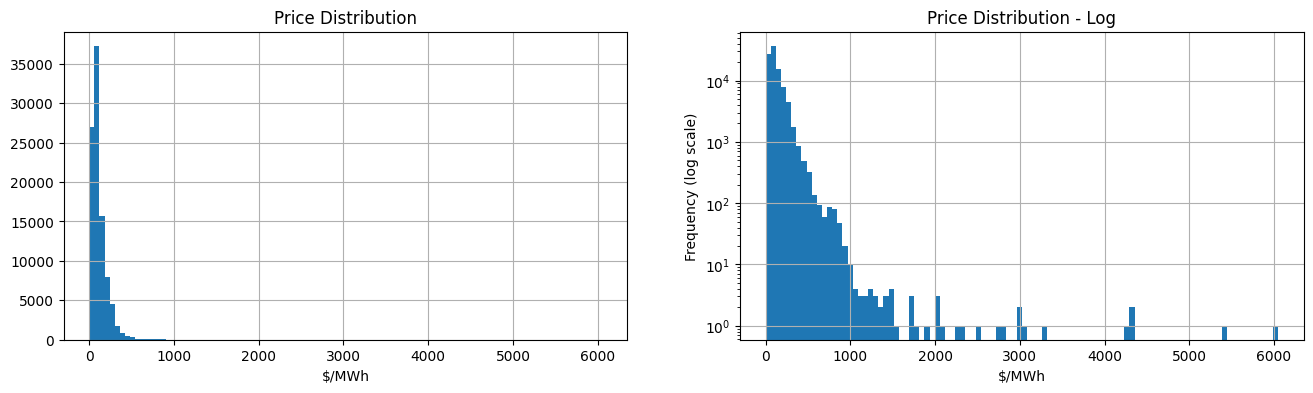

In [8]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
df['el_price_dol_MWh_OTA2201'].hist(bins=100)
plt.title('Price Distribution')
plt.xlabel('$/MWh')

plt.subplot(1, 2, 2)
df['el_price_dol_MWh_OTA2201'].hist(bins=100)
plt.yscale('log')
plt.title('Price Distribution - Log')
plt.xlabel('$/MWh')
plt.ylabel('Frequency (log scale)')

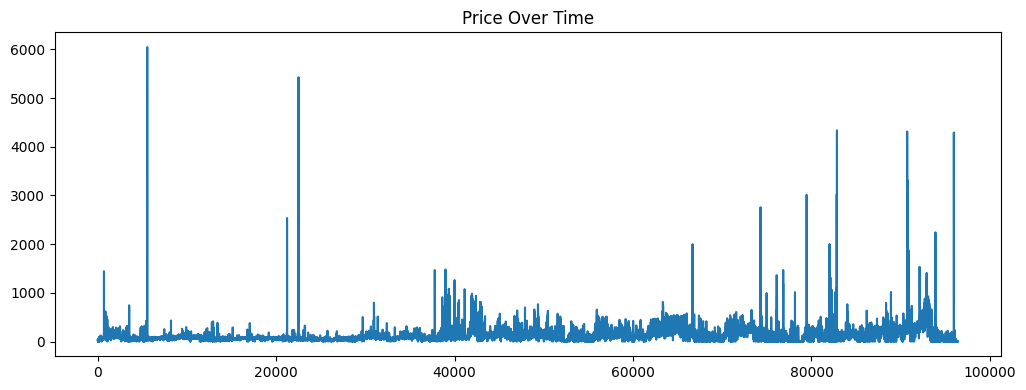

In [9]:
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 2)
df['el_price_dol_MWh_OTA2201'].plot()
plt.title('Price Over Time')
plt.tight_layout()
plt.show()

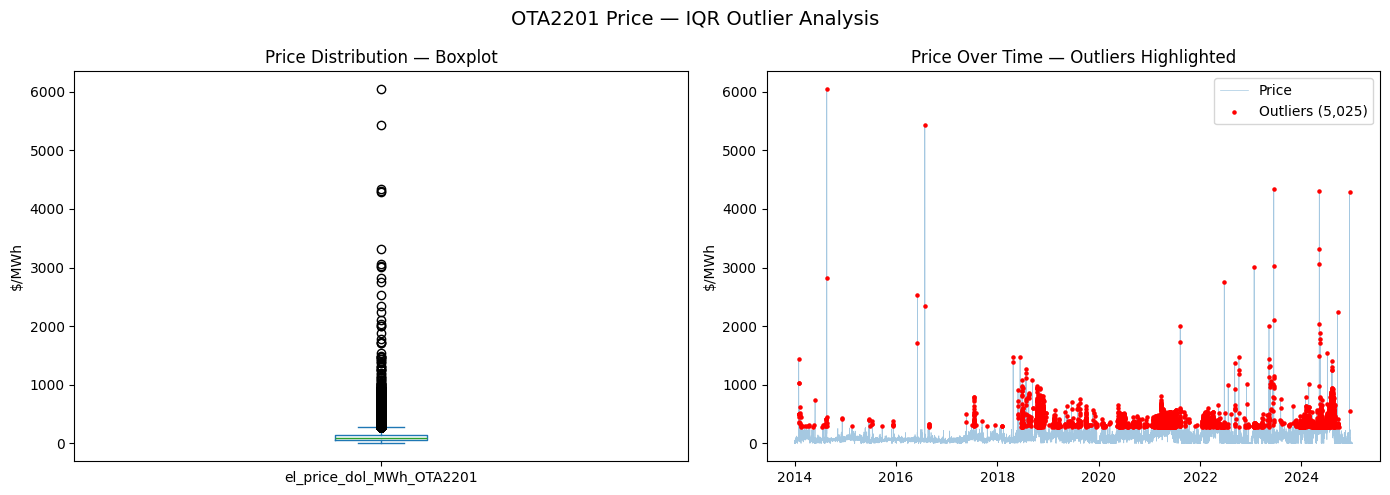

IQR bounds  : [-78.05, 283.54]
Total outliers: 5,025 (5.21% of data)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['el_price_dol_MWh_OTA2201'].plot(kind='box', ax=axes[0])
axes[0].set_title('Price Distribution — Boxplot')
axes[0].set_ylabel('$/MWh')

# Identify outliers using IQR method
Q1  = df['el_price_dol_MWh_OTA2201'].quantile(0.25)
Q3  = df['el_price_dol_MWh_OTA2201'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['el_price_dol_MWh_OTA2201'] < lower) |
    (df['el_price_dol_MWh_OTA2201'] > upper)
]

# Plot with outliers highlighted
axes[1].plot(df['datetime_utc12'], df['el_price_dol_MWh_OTA2201'], alpha=0.4, linewidth=0.5, label='Price')
axes[1].scatter(outliers['datetime_utc12'], outliers['el_price_dol_MWh_OTA2201'],
                color='red', s=5, label=f'Outliers ({len(outliers):,})', zorder=5)
axes[1].set_title('Price Over Time — Outliers Highlighted')
axes[1].set_ylabel('$/MWh')
axes[1].legend()

plt.suptitle('OTA2201 Price — IQR Outlier Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'IQR bounds  : [{lower:.2f}, {upper:.2f}]')
print(f'Total outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% of data)')

In [11]:
df[df["el_price_dol_MWh_OTA2201"] > 1000].shape

(55, 85)

In [12]:
df.shape

(96408, 85)

## 3. Target over time — zoom into one year to see patterns

1 Year

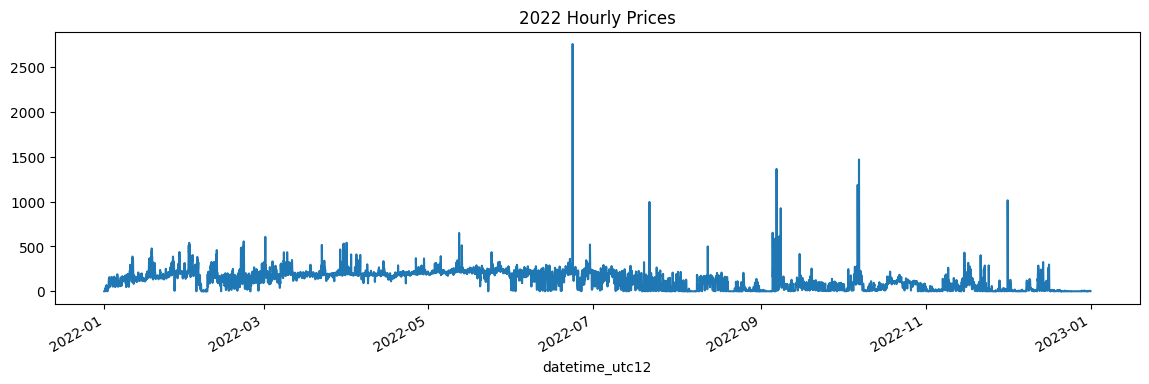

In [13]:
df[pd.to_datetime(df['datetime_utc12']).dt.year == 2022].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(figsize=(14, 4))
plt.title('2022 Hourly Prices')
plt.show()

4 Years

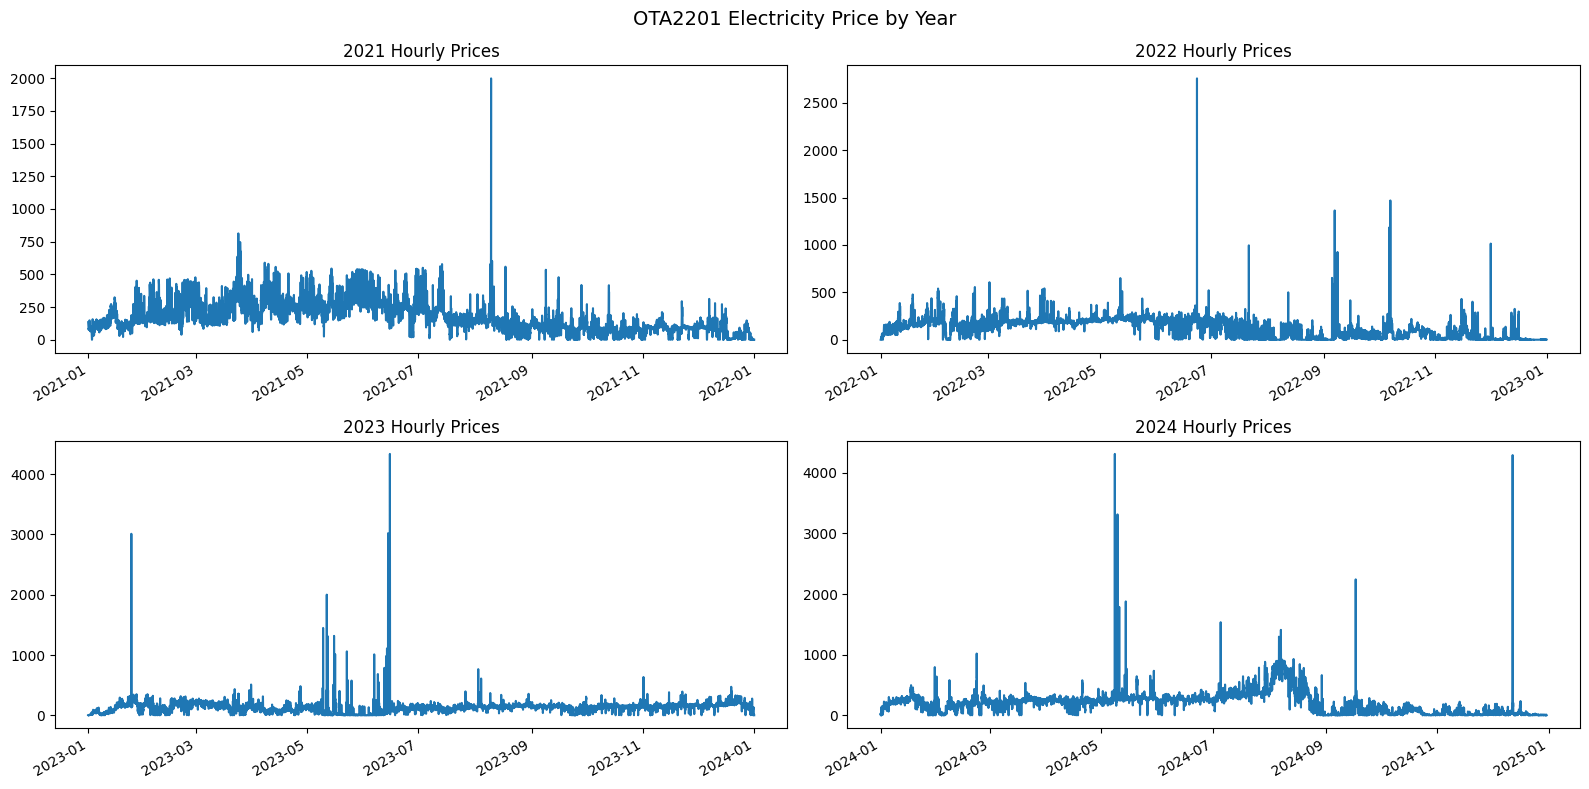

In [14]:
years = [2021, 2022, 2023, 2024]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year
    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year', fontsize=14)
plt.tight_layout()
plt.show()

6 Years

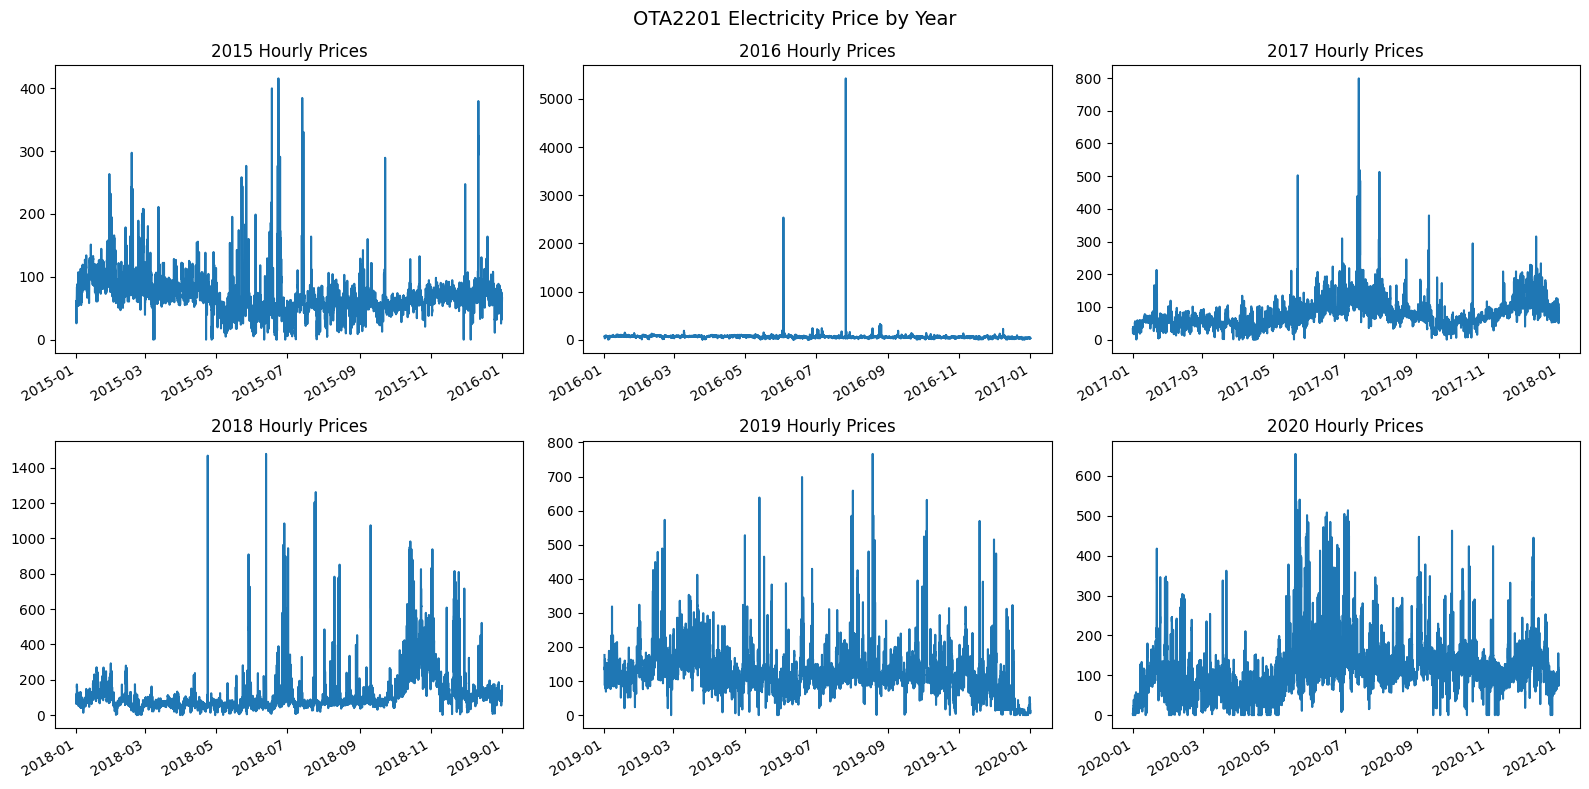

In [15]:
years = [2015, 2016, 2017, 2018, 2019, 2020]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year
    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year', fontsize=14)
plt.tight_layout()
plt.show()

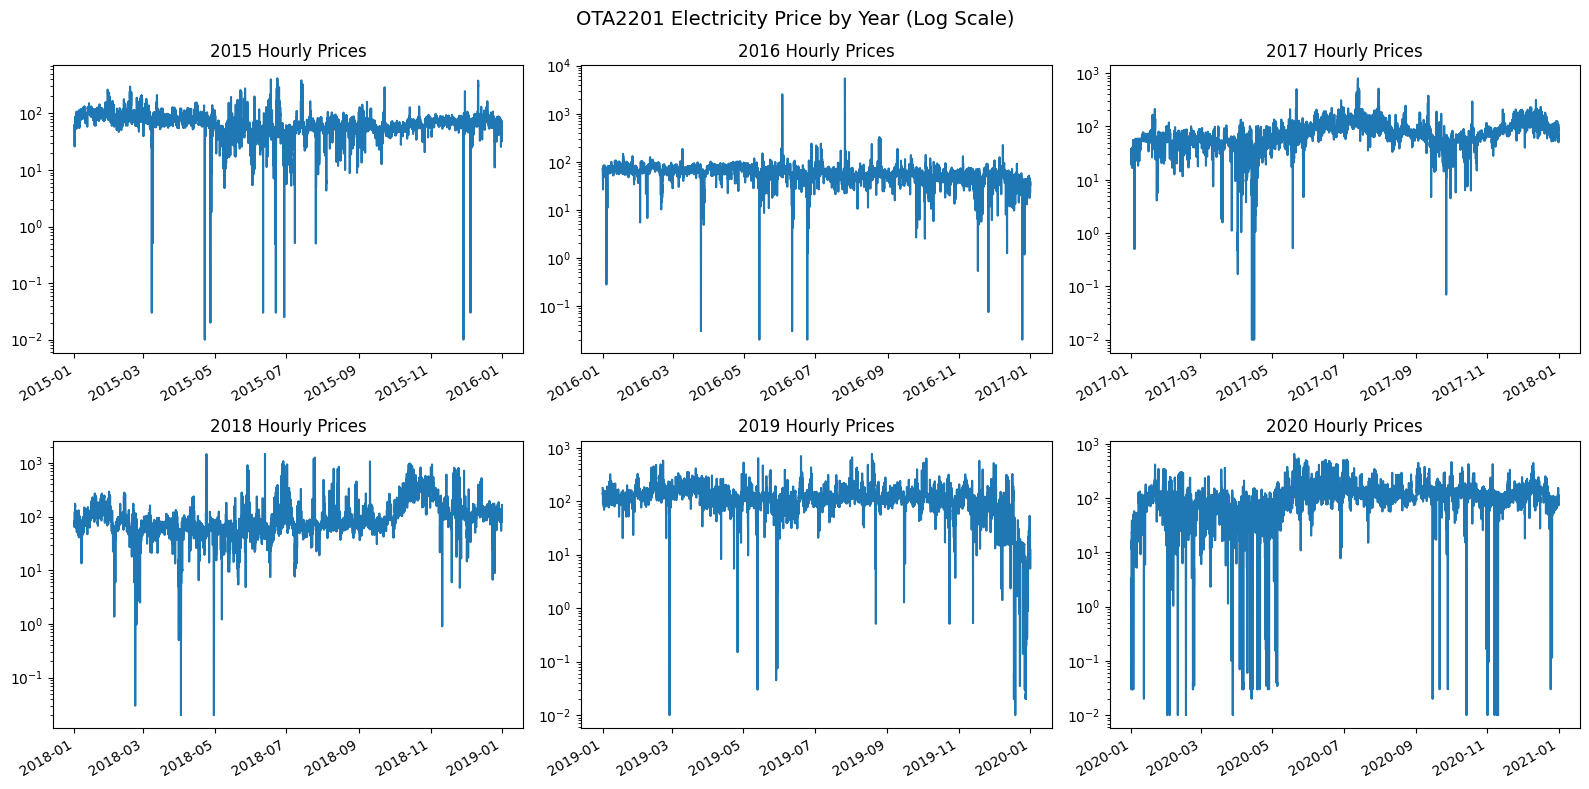

In [16]:
years = [2015, 2016, 2017, 2018, 2019, 2020]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, year in enumerate(years):
    mask = pd.to_datetime(df['datetime_utc12']).dt.year == year

    df[mask].set_index('datetime_utc12')['el_price_dol_MWh_OTA2201'].plot(ax=axes[i])

    axes[i].set_yscale('log')  # Log scale
    axes[i].set_title(f'{year} Hourly Prices')
    axes[i].set_xlabel('')

plt.suptitle('OTA2201 Electricity Price by Year (Log Scale)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Seasonality checks

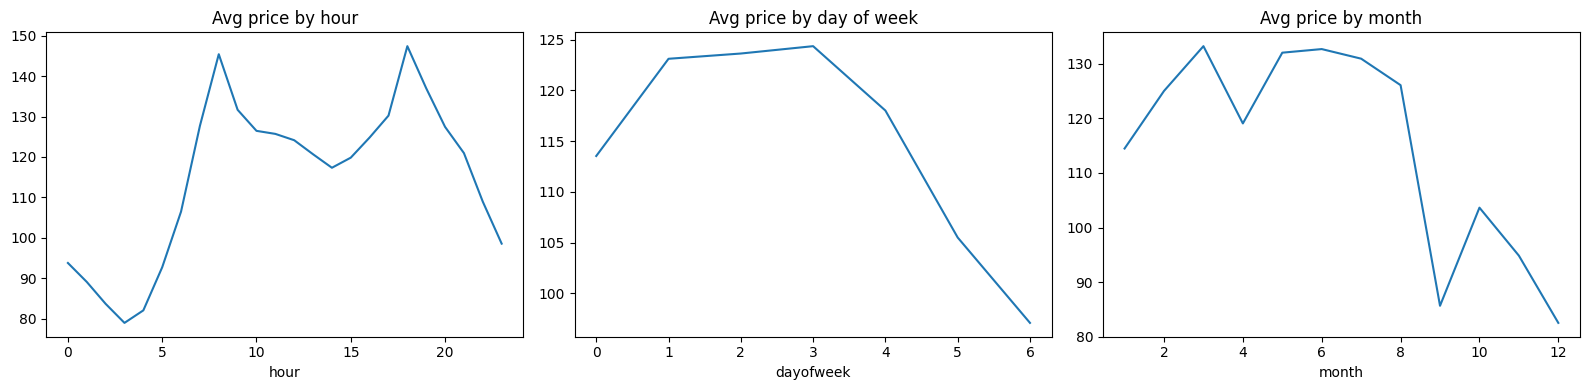

In [17]:
df['hour']       = pd.to_datetime(df['datetime_utc12']).dt.hour
df['dayofweek']  = pd.to_datetime(df['datetime_utc12']).dt.dayofweek
df['month']      = pd.to_datetime(df['datetime_utc12']).dt.month

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.groupby('hour')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[0], title='Avg price by hour')
df.groupby('dayofweek')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[1], title='Avg price by day of week')
df.groupby('month')['el_price_dol_MWh_OTA2201'].mean().plot(ax=axes[2], title='Avg price by month')
plt.tight_layout()
plt.show()

# B. Features Analysis: Heatmap, Correlation, Feature Selection

## 1. Correlations

### Target Correlation

In [18]:
# Dropping day of the week, hour, and month
df = df.drop(columns=['hour', 'dayofweek', 'month'])

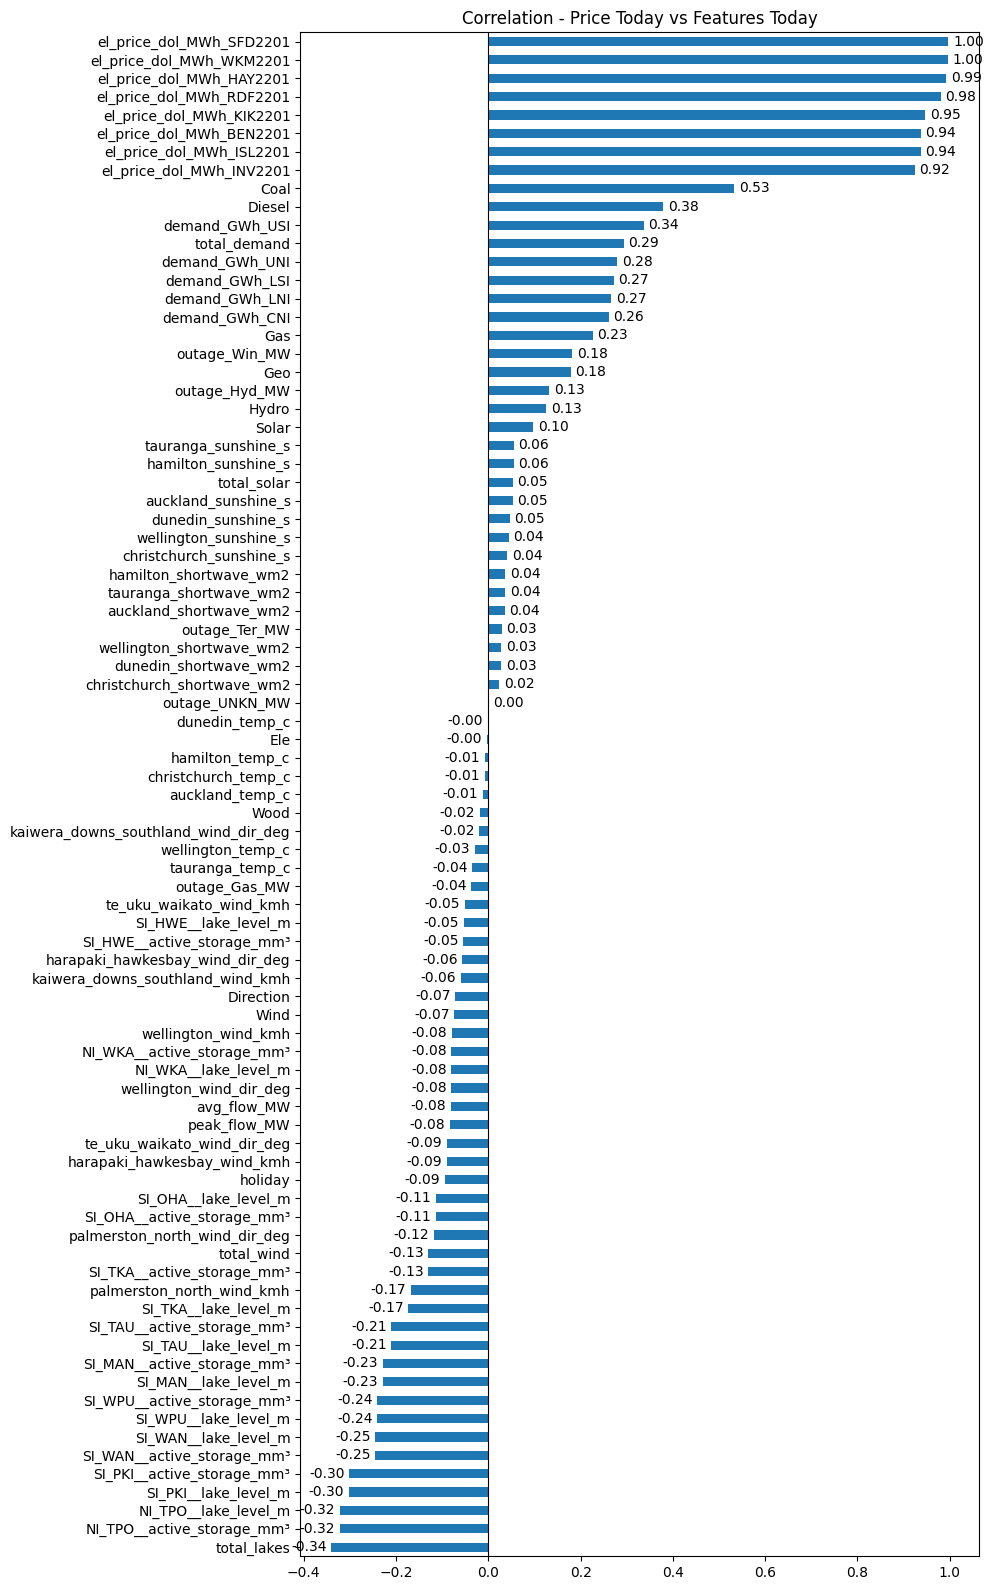

In [19]:
# Top correlations with target
corr = df.select_dtypes(include='number').corr()
target_corr = corr['el_price_dol_MWh_OTA2201'].drop('el_price_dol_MWh_OTA2201').sort_values()

fig, ax = plt.subplots(figsize=(10, 16))

target_corr.plot(kind='barh', ax=ax)

# Add labels
for i, value in enumerate(target_corr):
    ax.text(
        value + (0.01 if value >= 0 else -0.01),  # offset
        i,
        f'{value:.2f}',
        va='center',
        ha='left' if value >= 0 else 'right'
    )

ax.set_title('Correlation - Price Today vs Features Today')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

### 24h & 72h Lagged Correlation

In [20]:
target = "el_price_dol_MWh_OTA2201"

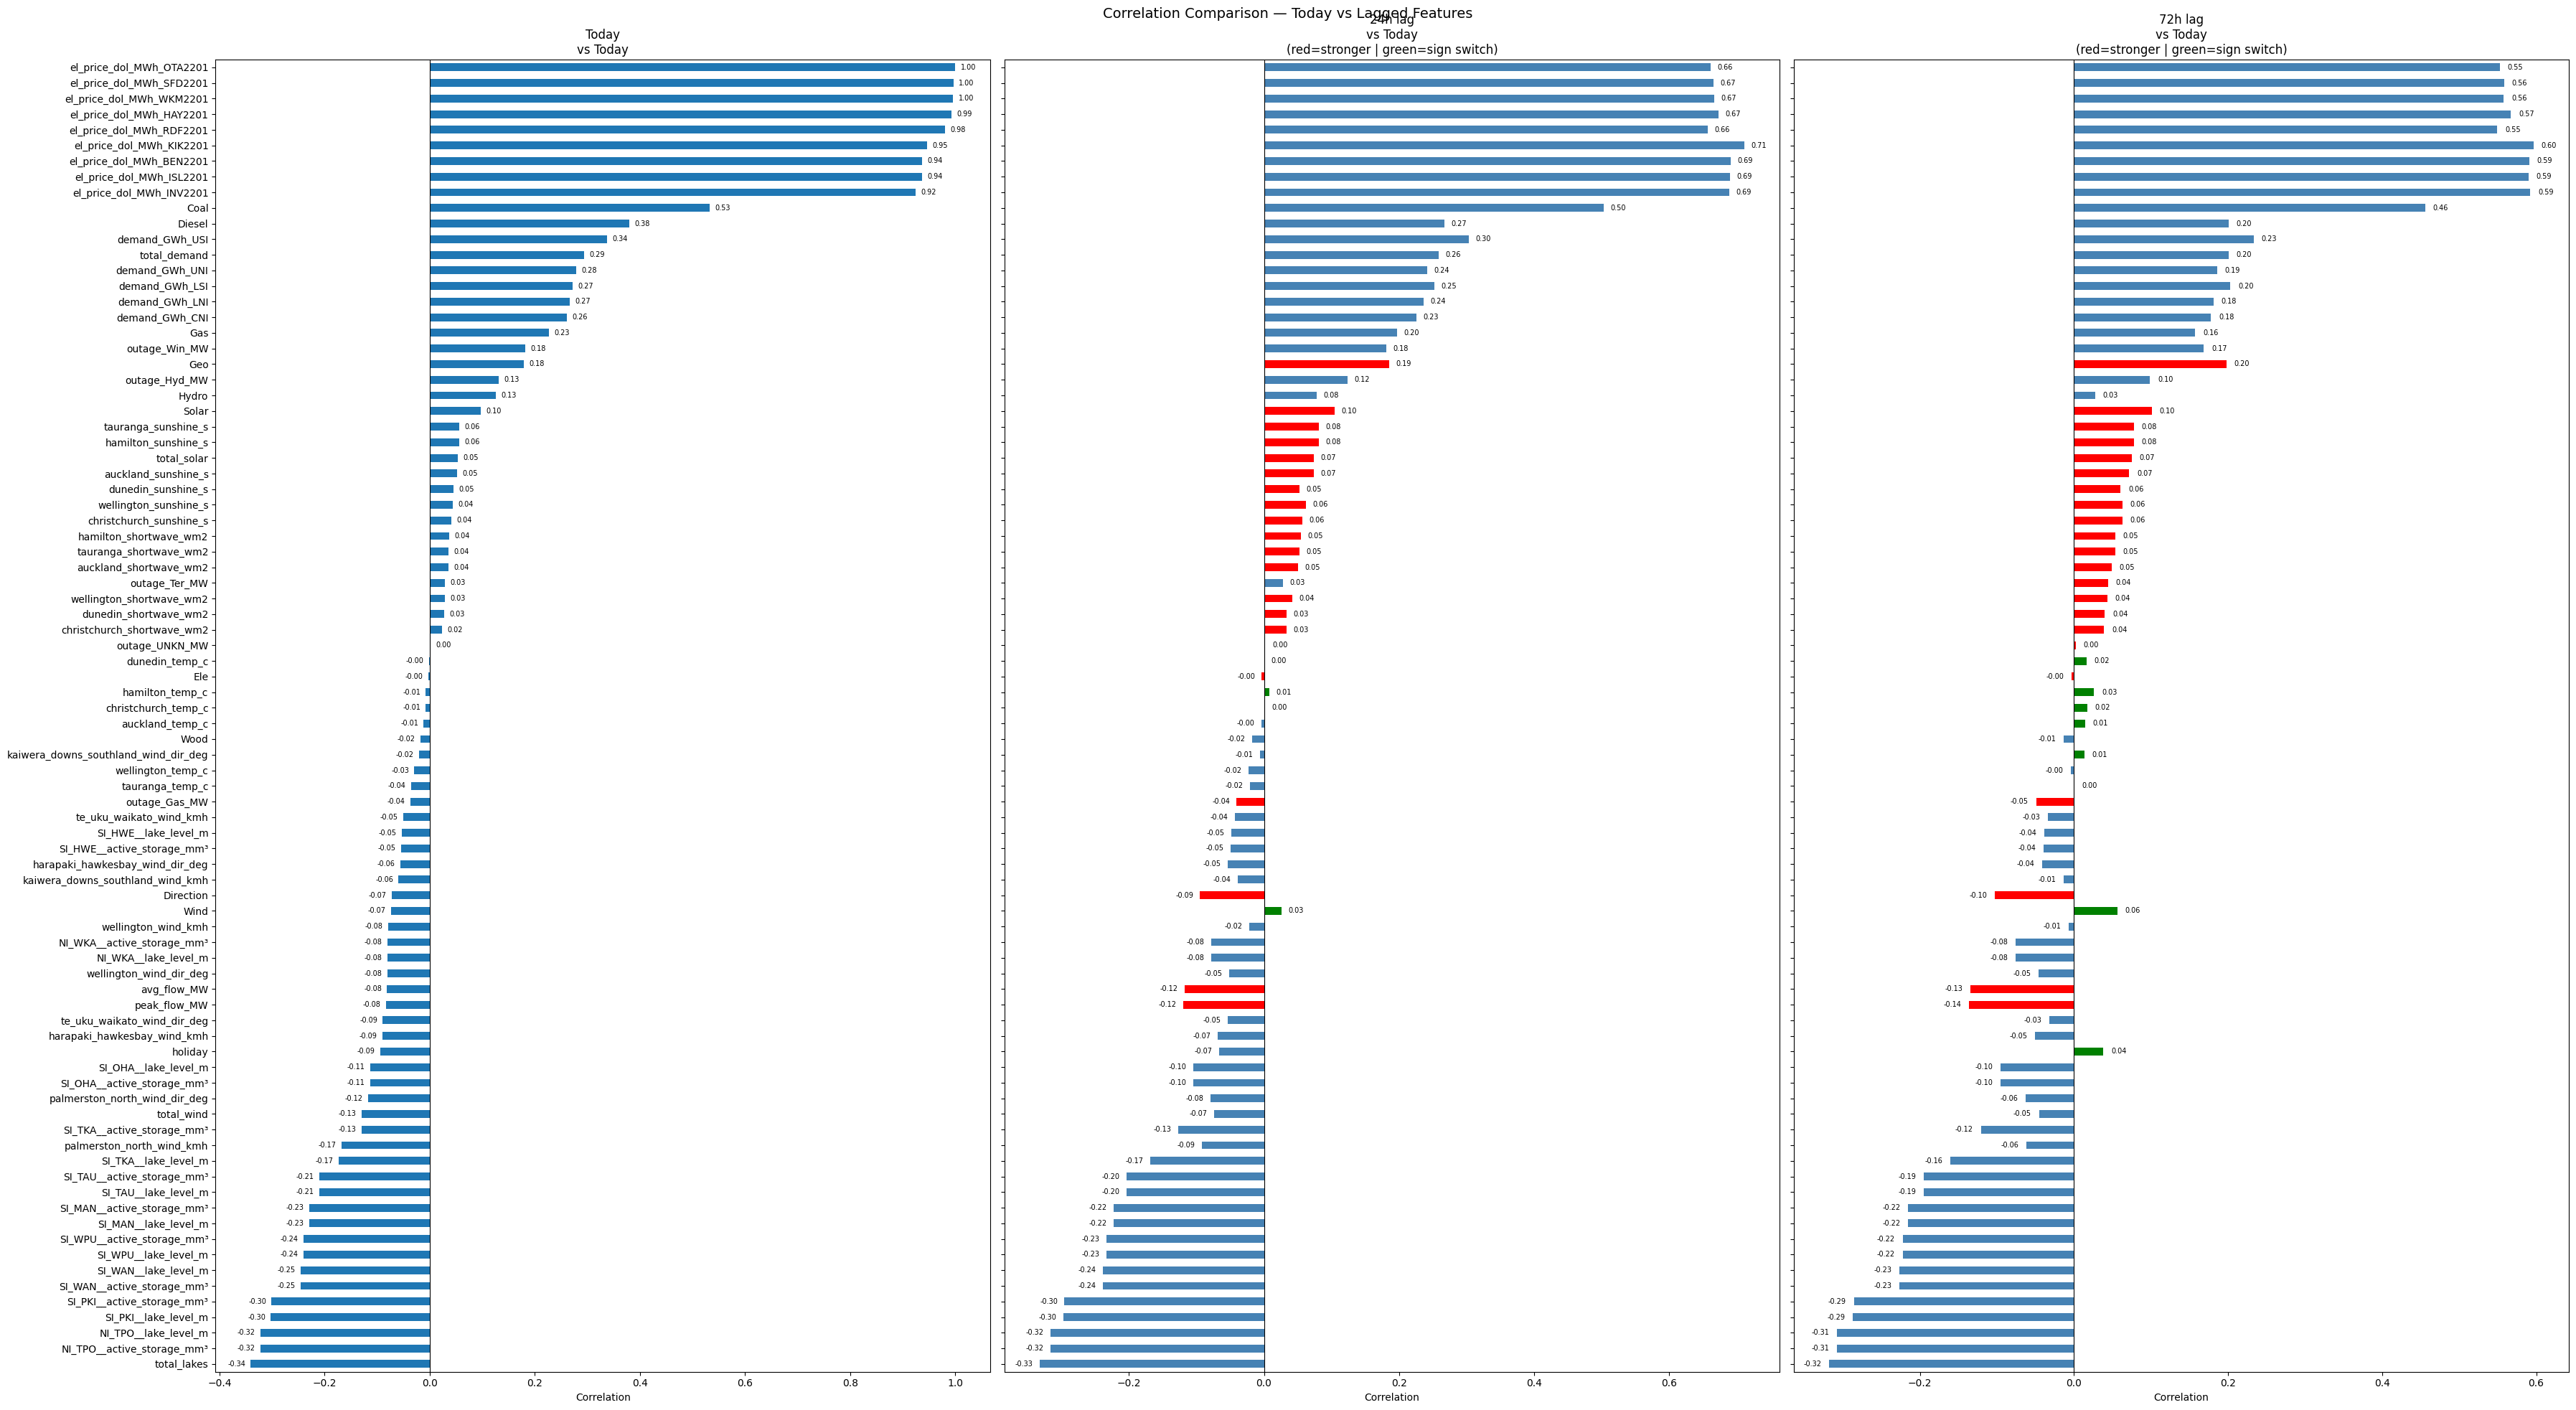

In [21]:
numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

# --- Lag configs ---
lag_configs = {
    '24h lag':  24,
    '72h lag':  72,
}

# --- Output DataFrames ---
corr_24  = None
corr_72  = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours).copy()
    df_lagged['_y_now_'] = df[target]                  # ← aux column, leaves lagged target intact
    corr_lagged = df_lagged.corr()['_y_now_'].drop('_y_now_')

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_24  = output_map[24]
corr_72  = output_map[72]


# --- All features (flagged + unchanged) ---
for lag_hours in [24, 72]:
    df_lagged_all = numeric_df.shift(lag_hours).copy()
    df_lagged_all['_y_now_'] = df[target]
    corr_lagged_aligned = (
        df_lagged_all.corr()['_y_now_']
        .drop('_y_now_')
        [corr_today.index]
    )

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 24:
        corr_24_all = all_df
    else:
        corr_72_all = all_df


# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

### 168h & 336h Lagged Correlation

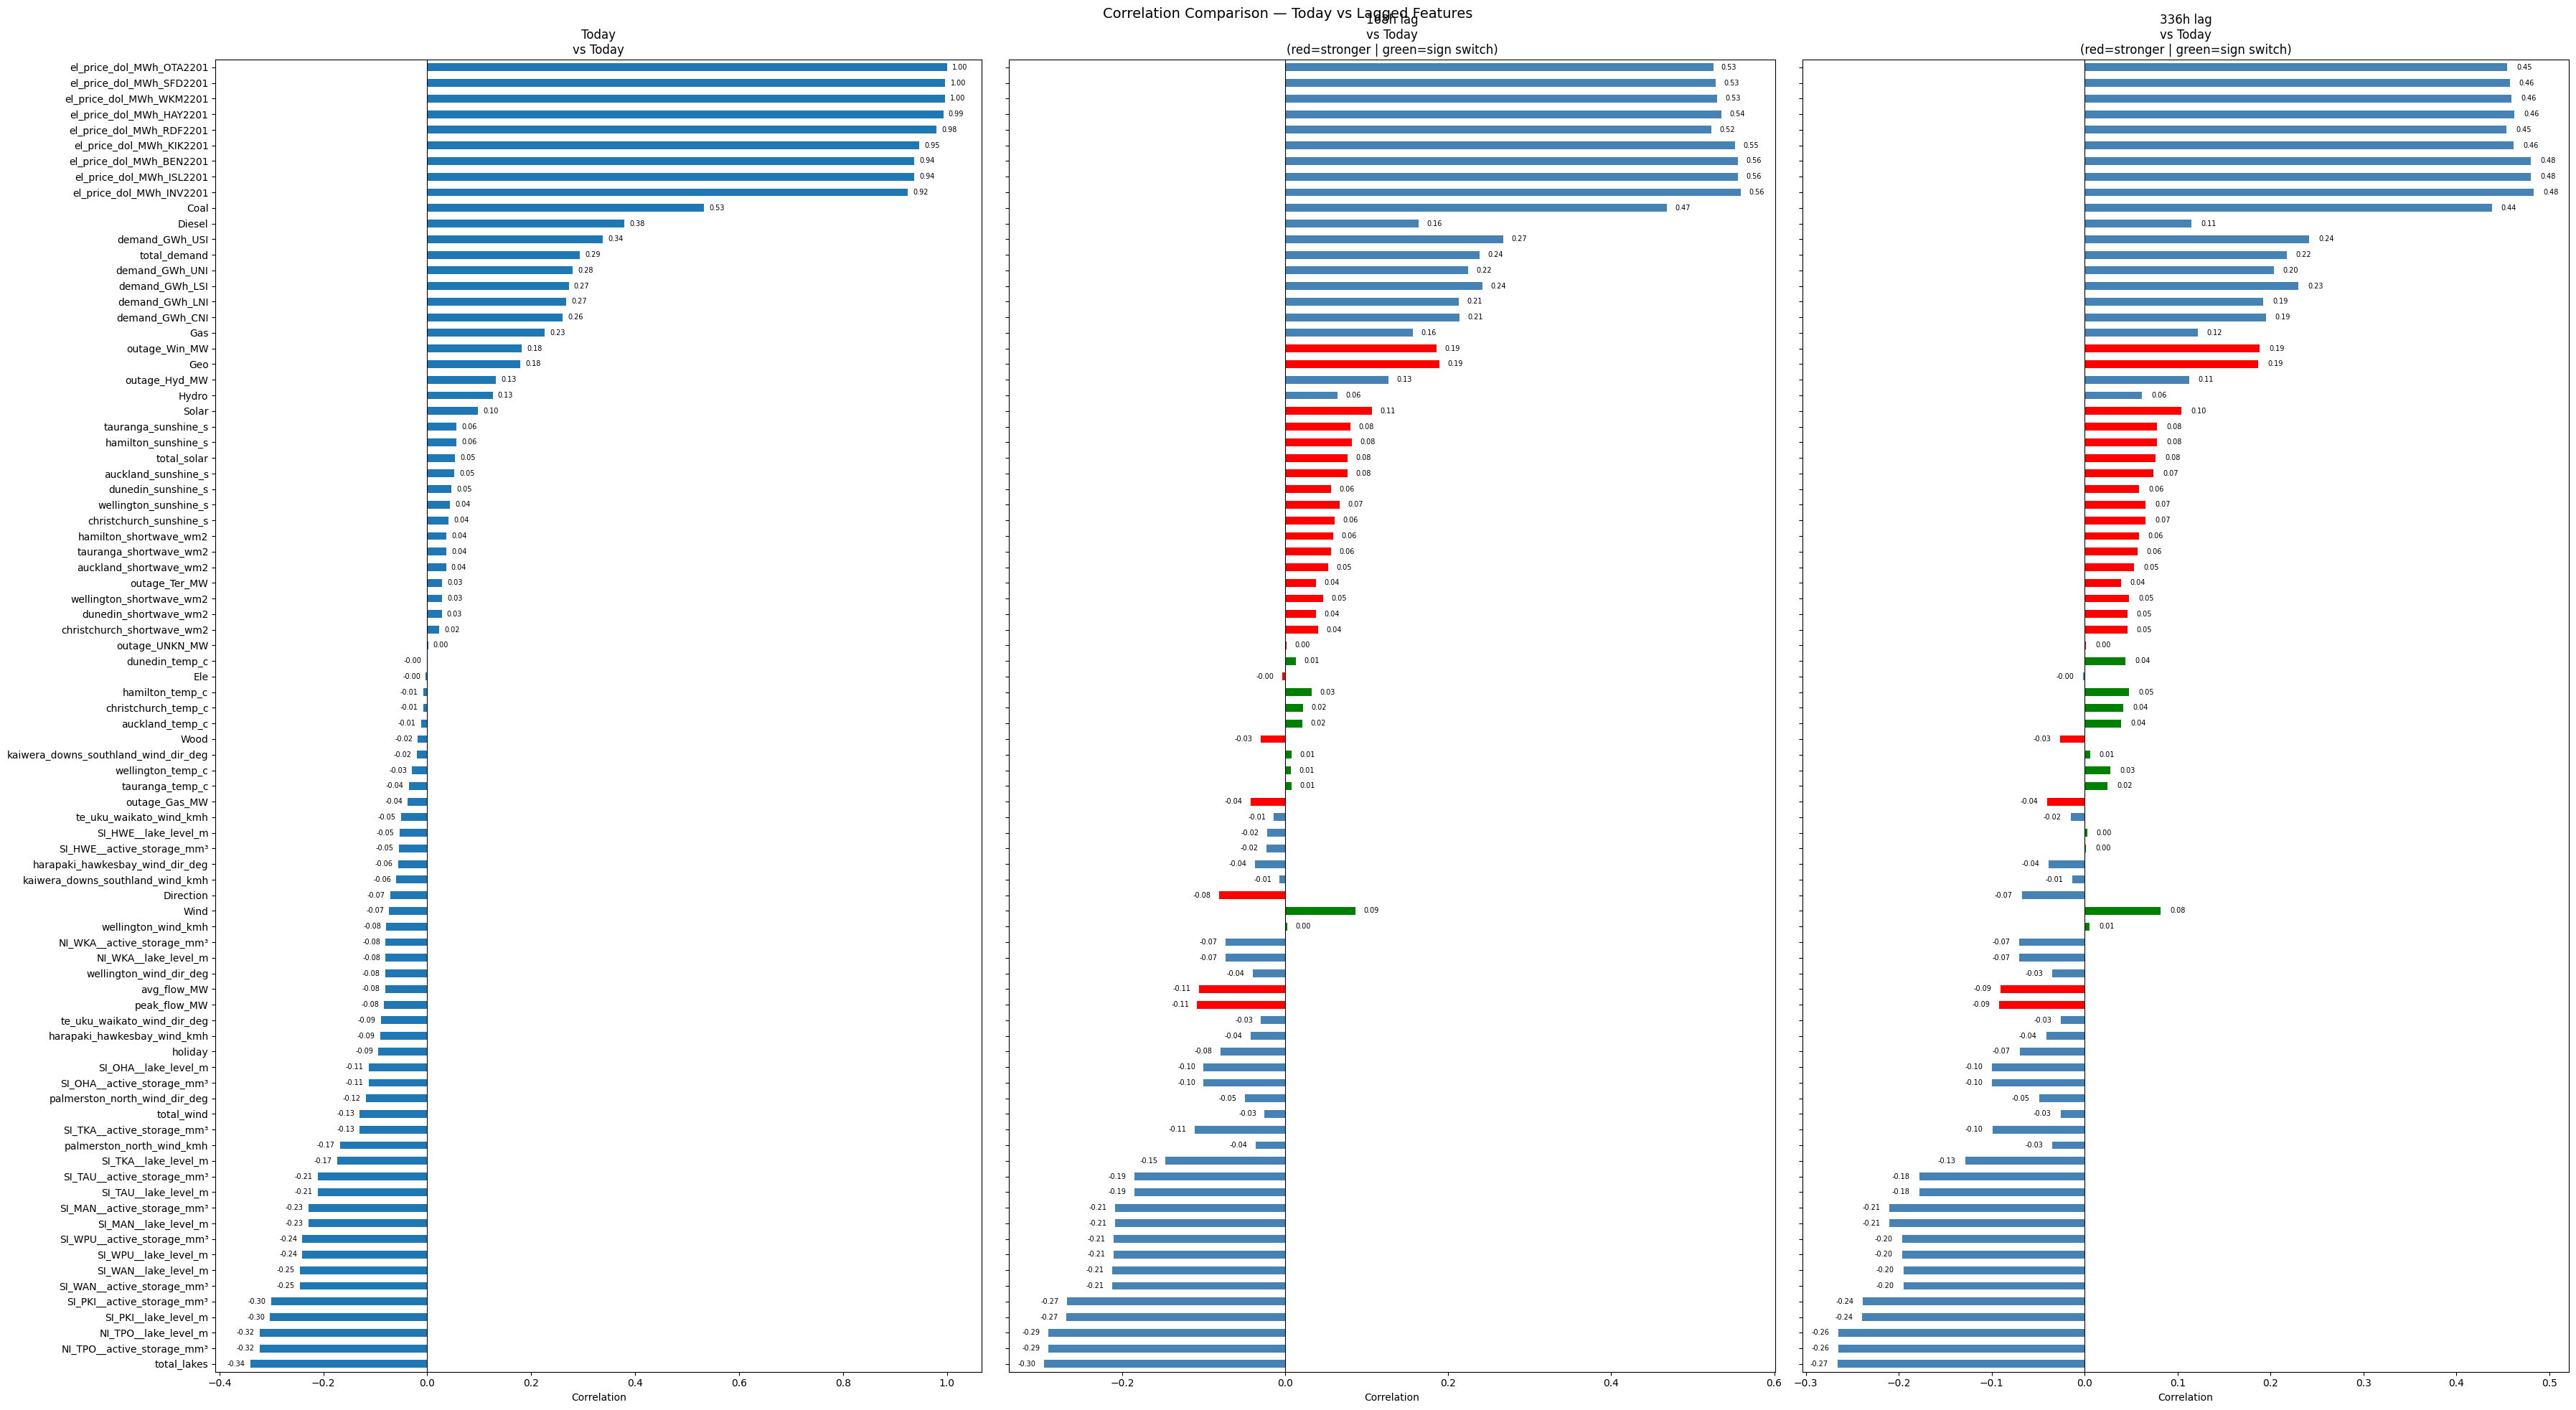

In [22]:

numeric_df = df.select_dtypes(include='number')

# --- Today correlation (anchor for all comparisons) ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

# --- Lag configs ---
lag_configs = {
    '168h lag': 168,
    '336h lag': 336
}

# --- Output DataFrames ---
corr_168 = None
corr_336 = None
output_map = {}  # will populate below

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(36, 20), sharey=True)

# Plot Today on first axis
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today\nvs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# --- Loop over lags ---
for ax, (lag_label, lag_hours) in zip(axes[1:], lag_configs.items()):

    # Compute lagged correlation
    df_lagged = numeric_df.shift(lag_hours).copy()
    df_lagged['_y_now_'] = df[target]                  # ← aux column, leaves lagged target intact
    corr_lagged = df_lagged.corr()['_y_now_'].drop('_y_now_')

    # Align to today's order
    corr_lagged_aligned = corr_lagged[corr_today.index]

    # --- Flags ---
    sign_switch  = (corr_today * corr_lagged_aligned) < 0
    abs_improved = (corr_lagged_aligned.abs() > corr_today.abs()) & ~sign_switch

    # --- Colors ---
    colors = []
    for feat in corr_today.index:
        if sign_switch[feat]:
            colors.append('green')
        elif abs_improved[feat]:
            colors.append('red')
        else:
            colors.append('steelblue')

    # --- Plot lag chart ---
    corr_lagged_aligned.plot(kind='barh', ax=ax, color=colors)
    for i, value in enumerate(corr_lagged_aligned):
        ax.text(
            value + (0.01 if value >= 0 else -0.01),
            i, f'{value:.2f}',
            va='center', ha='left' if value >= 0 else 'right', fontsize=7
        )
    ax.set_title(f'{lag_label}\nvs Today\n(red=stronger | green=sign switch)')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Correlation')

    # --- Build summary DataFrame (flagged features only) ---
    flagged = abs_improved | sign_switch

    summary = pd.DataFrame({
        'feature':        corr_today.index[flagged],
        'corr_today':     corr_today[flagged].values,
        f'corr_{lag_hours}h': corr_lagged_aligned[flagged].values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0 else 'abs_improved', axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    summary = summary[['feature', 'corr_today', f'corr_{lag_hours}h', 'abs_change', 'pct_change', 'flag']]

    output_map[lag_hours] = summary

plt.suptitle('Correlation Comparison — Today vs Lagged Features', fontsize=14)
plt.tight_layout()
plt.show()

# --- Assign to named variables ---
corr_168 = output_map[168]
corr_336 = output_map[336]

# --- All features (flagged + unchanged) ---
for lag_hours in [168, 336]:
    df_lagged_all = numeric_df.shift(lag_hours).copy()
    df_lagged_all['_y_now_'] = df[target]
    corr_lagged_aligned = (
        df_lagged_all.corr()['_y_now_']
        .drop('_y_now_')
        [corr_today.index]
    )

    all_df = pd.DataFrame({
        'feature':            corr_today.index,
        'corr_today':         corr_today.values,
        f'corr_{lag_hours}h': corr_lagged_aligned.values,
    }).assign(
        abs_change = lambda x: (x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()),
        pct_change = lambda x: ((x[f'corr_{lag_hours}h'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
        flag       = lambda x: x.apply(
            lambda r: 'sign_switch' if (r['corr_today'] * r[f'corr_{lag_hours}h']) < 0
                      else ('abs_improved' if abs(r[f'corr_{lag_hours}h']) > abs(r['corr_today'])
                      else 'unchanged'), axis=1
        )
    ).sort_values('abs_change', ascending=False).reset_index(drop=True)

    if lag_hours == 168:
        corr_168_all = all_df
    else:
        corr_336_all = all_df

# --- Print summaries ---
# for hours, df_out in [(24, corr_24), (72, corr_72), (168, corr_168), (336, corr_336)]:
#     flagged_count = len(df_out)
#     improved = (df_out['flag'] == 'abs_improved').sum()
#     switched = (df_out['flag'] == 'sign_switch').sum()
#     print(f'\ncorr_{hours}h — {flagged_count} flagged ({improved} stronger, {switched} sign switches):')
#     print(df_out.to_string(index=False))

### 7 Day Moving Average Lagged Correlation

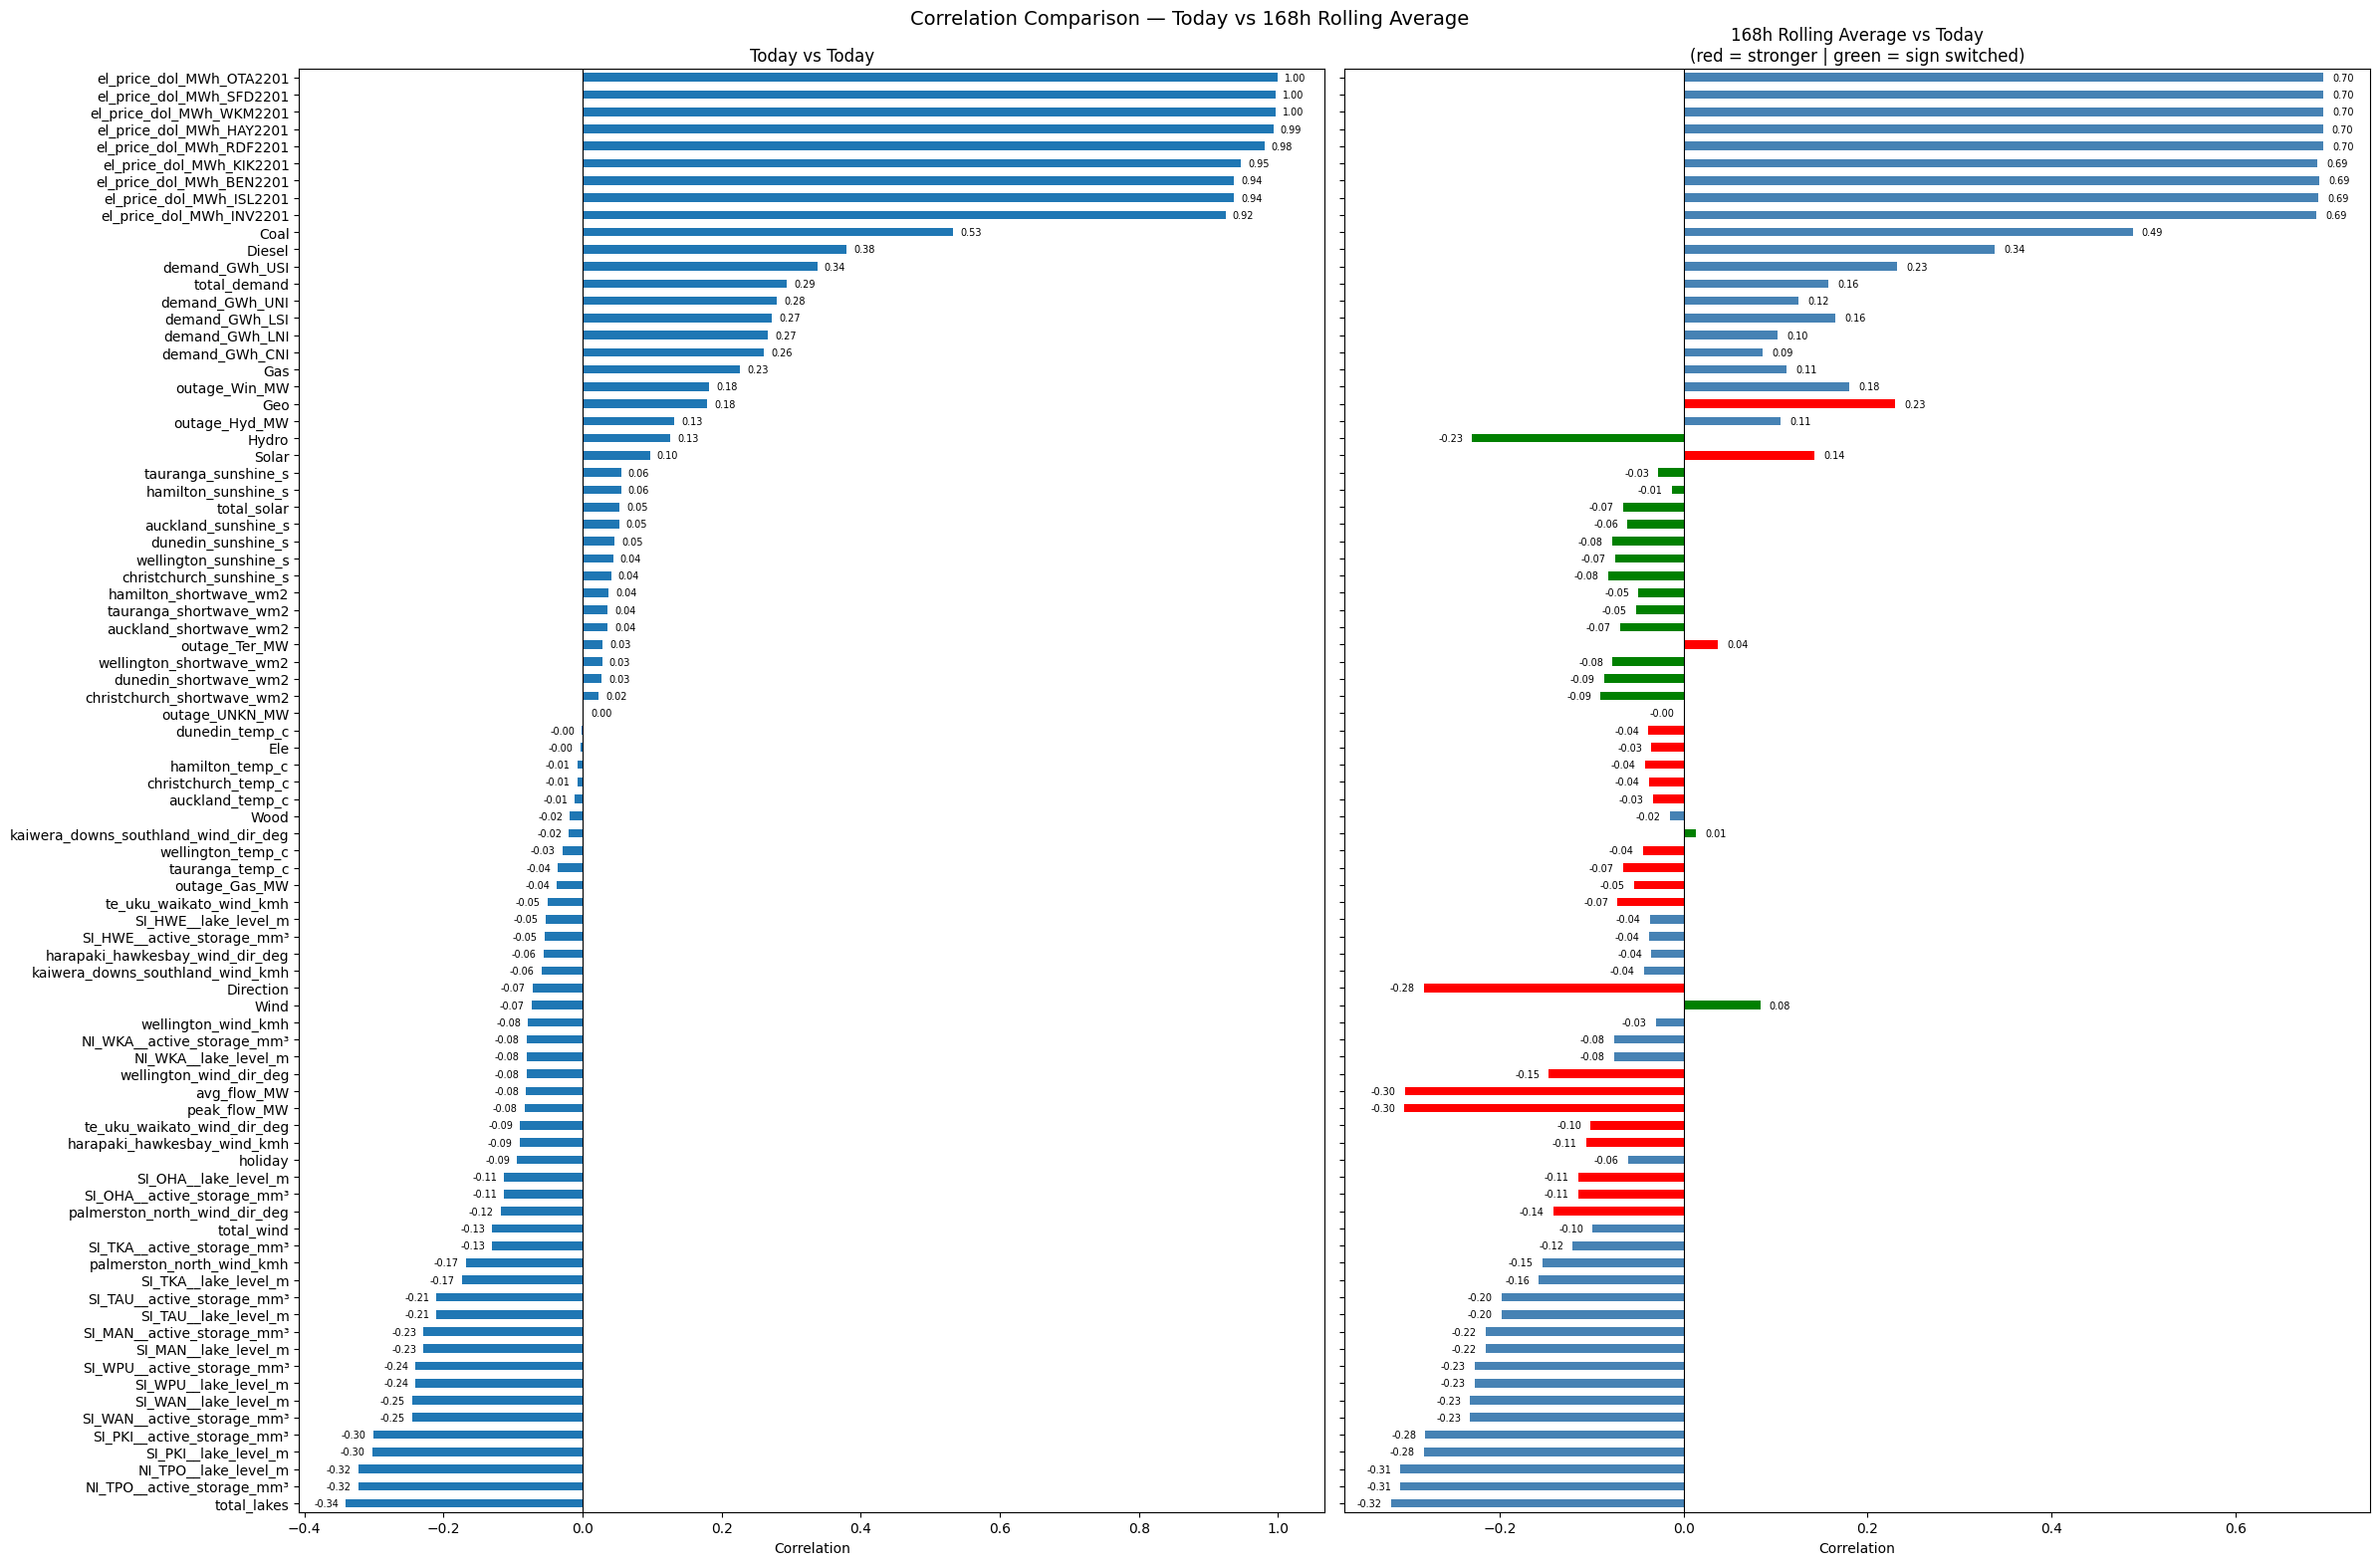

In [23]:

numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

df_rolling = numeric_df.shift(1).rolling(window=168).mean()
df_rolling['_y_now_'] = df[target]                                   # ← aux, doesn't overwrite rolling target
corr_rolling = df_rolling.corr()['_y_now_'].drop('_y_now_')

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0                        # green: sign flipped
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch  # red: stronger, same sign

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

# Today chart
corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

# Rolling chart
corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('168h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 168h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':          corr_today.index[flagged],
    'corr_today':       corr_today[flagged].values,
    'corr_rolling_168': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# Reorder columns
summary = summary[['feature', 'corr_today', 'corr_rolling_168', 'abs_change', 'pct_change', 'flag']]
corr_rolling_168 = summary

# Get all correlations
corr_rolling_168_all = pd.DataFrame({
    'feature':          corr_today.index,
    'corr_today':       corr_today.values,
    'corr_rolling_168': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_168'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_168'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_168']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_168']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

# print(f'{len(summary)} features flagged ({abs_improved.sum()} stronger, {sign_switch.sum()} sign switches):\n')
# print(summary.to_string(index=False))

### 3 Day Moving Average Lagged Correlation

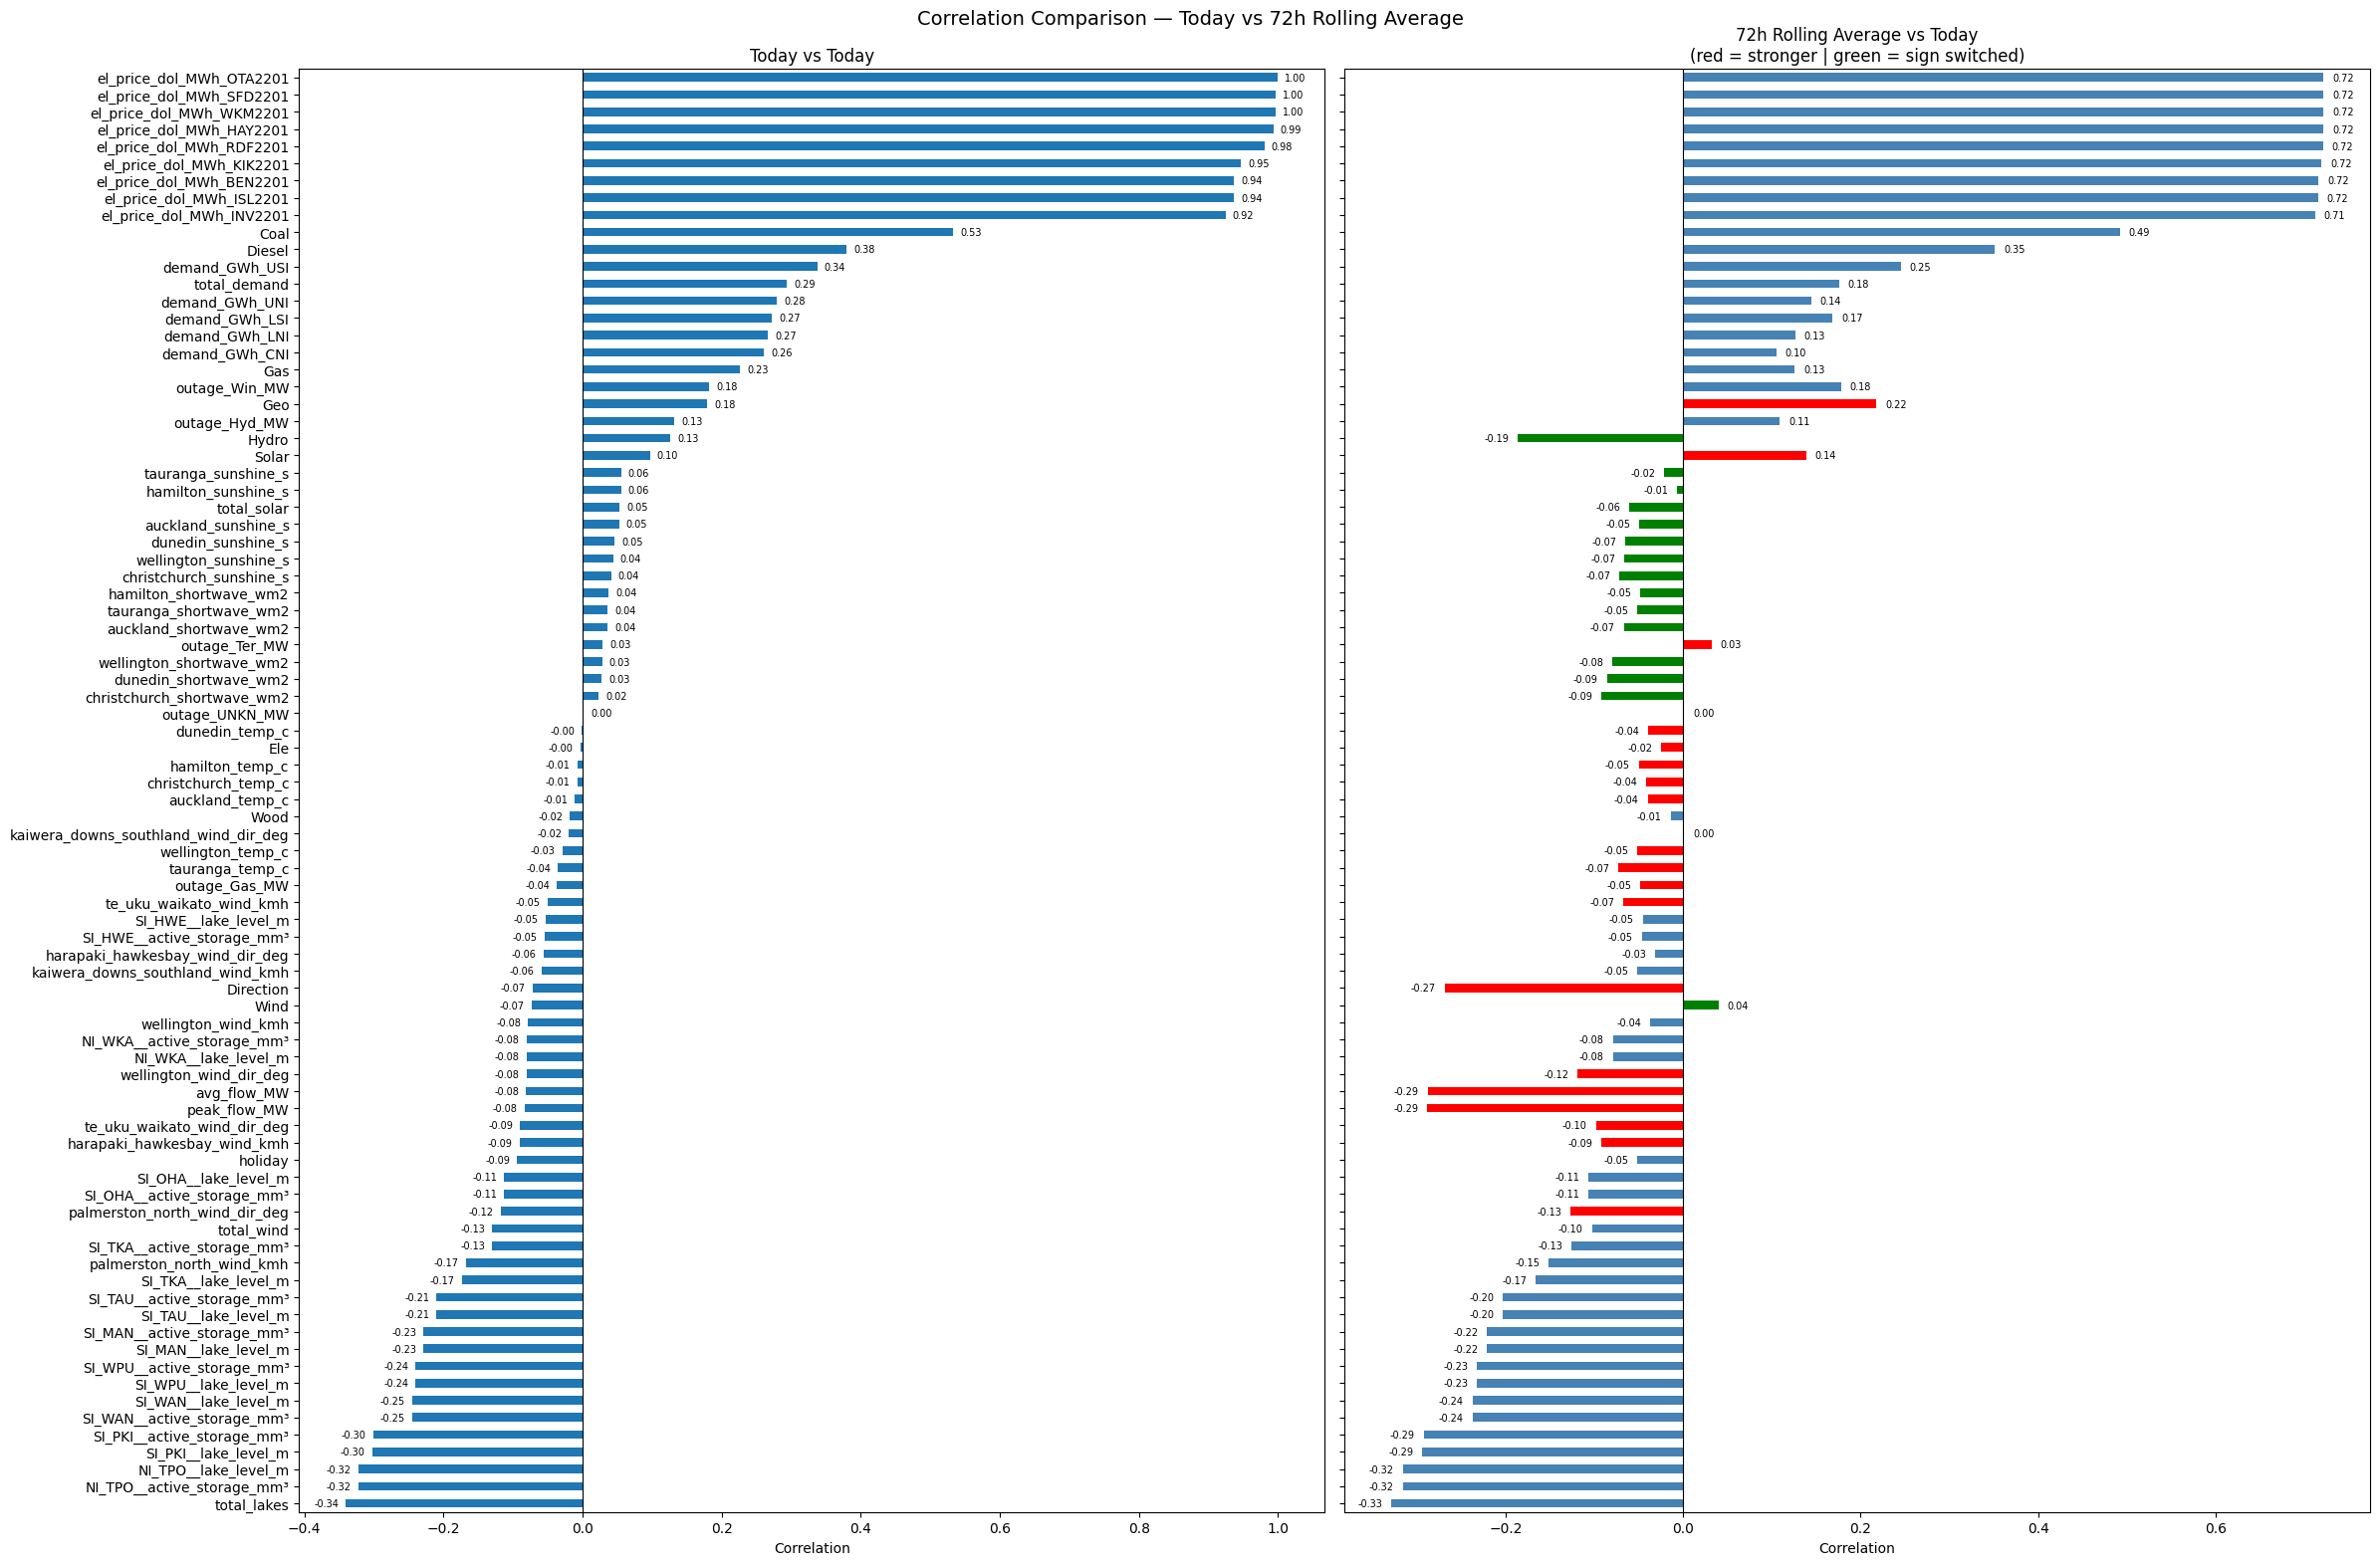

In [24]:
numeric_df = df.select_dtypes(include='number')

# --- Compute both correlations ---
df_today = numeric_df.copy()
df_today[target] = df[target]
corr_today = df_today.corr()[target].sort_values()   # ← removed .drop(target)

df_rolling = numeric_df.shift(1).rolling(window=72).mean()
df_rolling['_y_now_'] = df[target]                                   # ← aux, doesn't overwrite rolling target
corr_rolling = df_rolling.corr()['_y_now_'].drop('_y_now_')

# Align rolling to today's order
corr_rolling_aligned = corr_rolling[corr_today.index]

# --- Flags ---
sign_switch  = (corr_today * corr_rolling_aligned) < 0
abs_improved = (corr_rolling_aligned.abs() > corr_today.abs()) & ~sign_switch

# --- Colors ---
colors = []
for feat in corr_today.index:
    if sign_switch[feat]:
        colors.append('green')
    elif abs_improved[feat]:
        colors.append('red')
    else:
        colors.append('steelblue')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(24, 16), sharey=True)

corr_today.plot(kind='barh', ax=axes[0])
for i, value in enumerate(corr_today):
    axes[0].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[0].set_title('Today vs Today')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Correlation')

corr_rolling_aligned.plot(kind='barh', ax=axes[1], color=colors)
for i, value in enumerate(corr_rolling_aligned):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i, f'{value:.2f}',
        va='center', ha='left' if value >= 0 else 'right', fontsize=7
    )
axes[1].set_title('72h Rolling Average vs Today\n(red = stronger | green = sign switched)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation')

plt.suptitle('Correlation Comparison — Today vs 72h Rolling Average', fontsize=14)
plt.tight_layout()
plt.show()

# --- Summary DataFrame (red + green features) ---
flagged = abs_improved | sign_switch

summary = pd.DataFrame({
    'feature':         corr_today.index[flagged],
    'corr_today':      corr_today[flagged].values,
    'corr_rolling_72': corr_rolling_aligned[flagged].values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0 else 'abs_improved', axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

summary = summary[['feature', 'corr_today', 'corr_rolling_72', 'abs_change', 'pct_change', 'flag']]
corr_rolling_72 = summary

# --- All features ---
corr_rolling_72_all = pd.DataFrame({
    'feature':         corr_today.index,
    'corr_today':      corr_today.values,
    'corr_rolling_72': corr_rolling_aligned.values,
}).assign(
    abs_change = lambda x: (x['corr_rolling_72'].abs() - x['corr_today'].abs()),
    pct_change = lambda x: ((x['corr_rolling_72'].abs() - x['corr_today'].abs()) / x['corr_today'].abs() * 100).round(2),
    flag       = lambda x: x.apply(
        lambda r: 'sign_switch' if (r['corr_today'] * r['corr_rolling_72']) < 0
                  else ('abs_improved' if abs(r['corr_rolling_72']) > abs(r['corr_today'])
                  else 'unchanged'), axis=1
    )
).sort_values('abs_change', ascending=False).reset_index(drop=True)

All df correlations:
- corr_24_all
- corr_72_all
- corr_168_all
- corr_336_all
- corr_rolling_72_all
- corr_rolling_168_all

In [25]:
print(corr_24_all.shape)
print(corr_72_all.shape)
print(corr_168_all.shape)
print(corr_336_all.shape)
print(corr_rolling_72_all.shape)
print(corr_rolling_168_all.shape)

(84, 6)
(84, 6)
(84, 6)
(84, 6)
(84, 6)
(84, 6)


In [26]:
print(corr_24_all.columns.tolist())
print(corr_72_all.columns.tolist())
print(corr_168_all.columns.tolist())
print(corr_336_all.columns.tolist())
print(corr_rolling_72_all.columns.tolist())
print(corr_rolling_168_all.columns.tolist())

['feature', 'corr_today', 'corr_24h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_72h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_168h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_336h', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_rolling_72', 'abs_change', 'pct_change', 'flag']
['feature', 'corr_today', 'corr_rolling_168', 'abs_change', 'pct_change', 'flag']


## Log Transform Review

In [29]:
def review_distributions(df, skew_threshold=1.0):
    """
    Score each numeric feature's skewness and flag which need log1p.

    Rule of thumb:
      |skew| < 0.5    → roughly symmetric (no transform)
      0.5 ≤ |skew| < 1 → moderately skewed (optional)
      |skew| ≥ 1.0    → highly skewed (log1p recommended)

    Returns a DataFrame sorted by |skew|, descending.
    """
    rows = []
    for col in df.select_dtypes(include='number').columns:
        s = df[col].dropna()
        if len(s) == 0:
            continue

        sk      = skew(s)
        min_val = s.min()
        can_log = min_val >= 0                 # log1p needs non-negative data

        needs_log = (abs(sk) >= skew_threshold) and can_log

        rows.append({
            'feature':            col,
            'skew':               round(sk, 2),
            'min':                round(min_val, 2),
            'max':                round(s.max(), 2),
            'needs_log_transform': needs_log,
            'category':           ('highly skewed'     if abs(sk) >= 1.0
                                   else 'moderately skewed' if abs(sk) >= 0.5
                                   else 'roughly symmetric'),
        })

    return (
        pd.DataFrame(rows)
        .sort_values('skew', key=abs, ascending=False)
        .reset_index(drop=True)
    )

# Usage:
dist_summary = review_distributions(df)
print(dist_summary)
print(f"\nFeatures recommended for log1p: {dist_summary['needs_log_transform'].sum()}")

                     feature    skew        min         max  \
0                        Ele  310.44       0.00     4886.00   
1                     Diesel   13.28       0.00   159612.00   
2   el_price_dol_MWh_RDF2201    9.18       0.00     5452.30   
3   el_price_dol_MWh_OTA2201    8.77       0.00     6046.32   
4   el_price_dol_MWh_WKM2201    8.35       0.00     5542.44   
..                       ...     ...        ...         ...   
79                     Hydro   -0.05  562382.00  4706415.00   
80      SI_HWE__lake_level_m    0.04     338.33      346.03   
81            demand_GWh_USI   -0.03       0.00        1.13   
82            demand_GWh_UNI    0.02       0.00        2.40   
83           auckland_temp_c   -0.01       2.00       26.60   

    needs_log_transform           category  
0                  True      highly skewed  
1                  True      highly skewed  
2                  True      highly skewed  
3                  True      highly skewed  
4                 

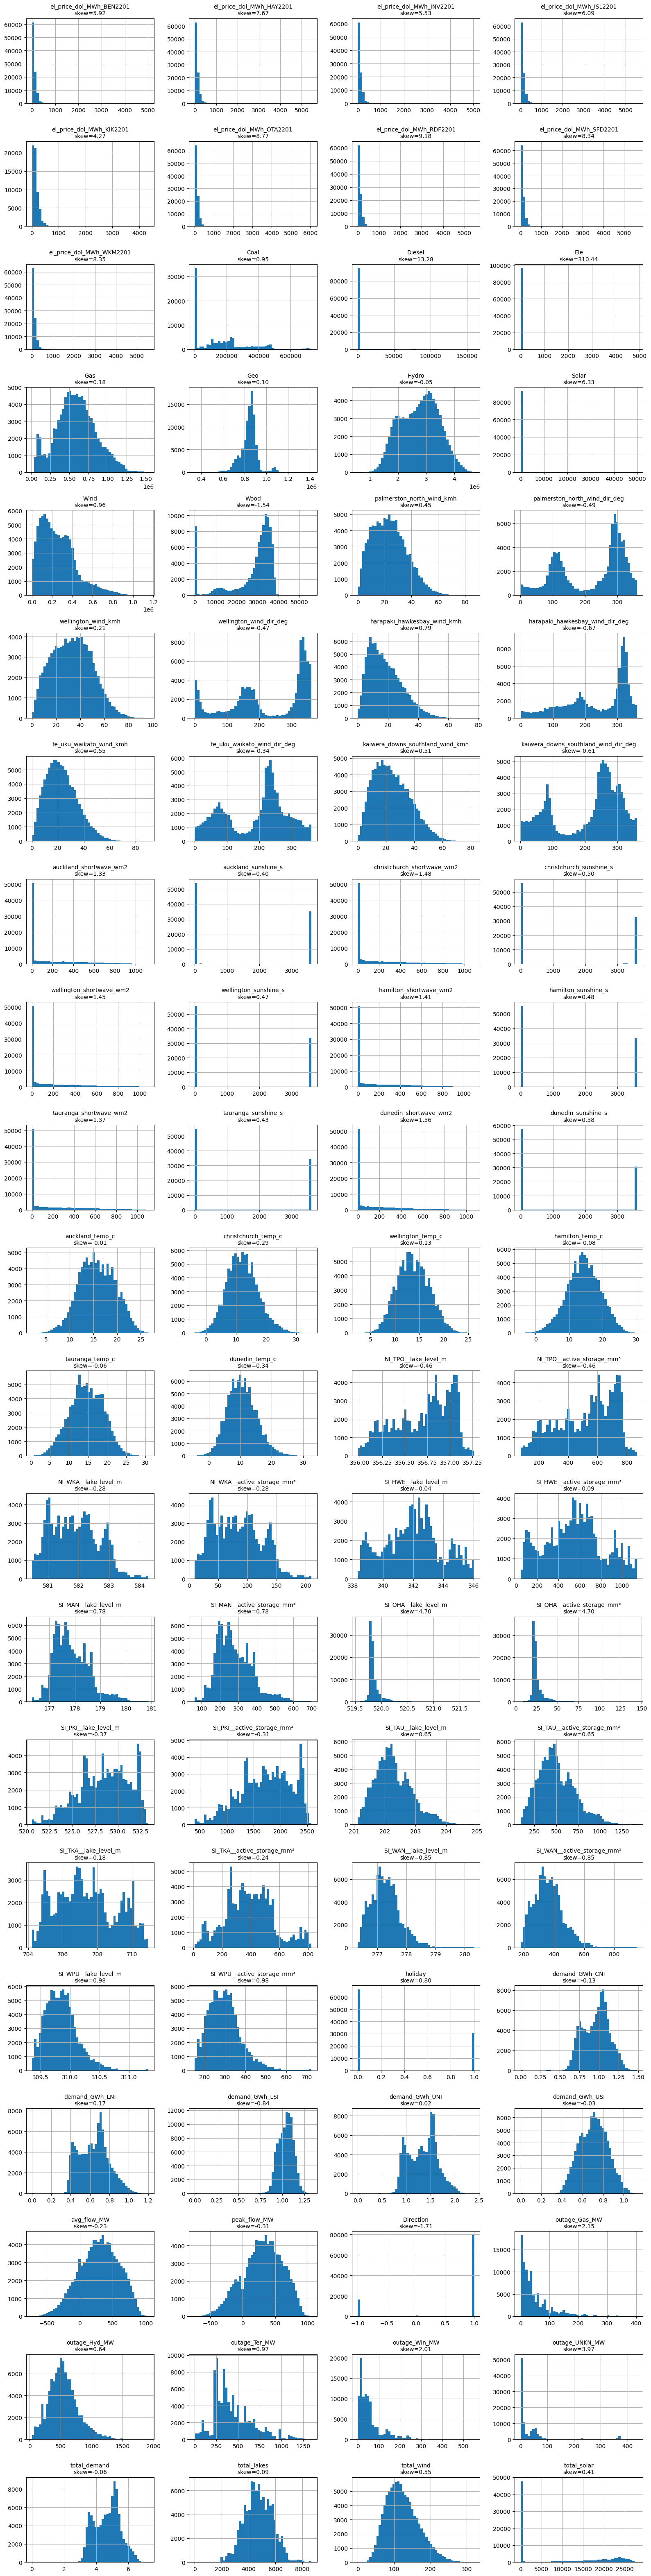

In [30]:
def plot_distributions(df, features=None, ncols=4):
    if features is None:
        features = df.select_dtypes(include='number').columns.tolist()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
    axes = axes.flatten()
    for i, col in enumerate(features):
        s = df[col].dropna()
        s.hist(bins=50, ax=axes[i])
        axes[i].set_title(f'{col}\nskew={s.skew():.2f}', fontsize=10)
    for j in range(len(features), len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

plot_distributions(df)

## Pipeline Differences at a Glance

|                                  | Linear           | XGBoost           | LSTM                          |
|----------------------------------|------------------|-------------------|-------------------------------|
| Target correlation cutoff        | ≥ 0.20           | ≥ 0.20            | ≥ 0.10                        |
| Build manual lag columns?        | Yes (top 2–3)    | Yes (top 2–3)     | No (free via window)          |
| Multicollinearity threshold      | > 0.7            | > 0.9             | > 0.95                        |
| Scale features?                  | Yes (StandardScaler) | No (scale-invariant) | Yes (built-in Normalization layer) |
| Transform skewed features (`log1p`)? | Yes          | Yes               | Yes (critical)                |
| Cyclical time features           | Required         | Helpful           | Required                      |
| Captures non-linear patterns     | No               | Yes               | Yes                           |
| Captures interactions            | No (unless built) | Yes (free)       | Yes (free)                    |

## Why Each Choice Differs by Model

- **Target correlation cutoff** — Linear/XGBoost use `0.20` because they need direct linear or split-based signal from each feature. LSTM uses `0.10` because it can find non-linear interactions a simple correlation misses, so we tolerate weaker linear signal to avoid dropping potentially valuable features.

- **Manual lag columns** — Linear/XGBoost get a feature value at a single point in time per row, so manual lags are the only way to expose past values. LSTM is fed a 3D window containing 168 past hours of every feature, so lags 1 through 168 are already available — adding manual lag columns would duplicate values the model already sees.

- **Multicollinearity threshold** — Linear models break under correlated features (unstable coefficients, inflated errors), so the strict `0.7` cutoff. XGBoost handles correlated features fine for predictions but feature importance becomes unstable, so `0.9` keeps importance interpretable. LSTM can combine correlated features however it wants internally, so only true near-duplicates (`0.95+`) are worth removing for parameter efficiency.

- **Scaling features** — Linear models with regularisation penalise features by magnitude (larger-scale features get less effectively penalised), so StandardScaler is non-negotiable. XGBoost is scale-invariant because tree splits compare values to thresholds, immune to magnitude — applying a scaler has no effect on the model. LSTM uses a built-in `Normalization` layer that handles standard scaling cleanly and without leakage (it's fitted on training data only via `adapt()`).

- **Transforming skewed features (`log1p`)** — All three models benefit from log-transforming heavy-tailed features, but for different reasons. Linear models assume a linear relationship that breaks under heavy tails. XGBoost works but produces high-variance splits in sparse tail regions. LSTM is the most affected: the `Normalization` layer is StandardScaler under the hood, which squashes 99% of bulk values into a tiny range when applied to a heavy-tailed distribution, leaving the rare spikes as extreme outliers that dominate the gradient updates. Log-transforming first makes the distribution roughly Gaussian so standardisation works as intended.

- **Cyclical time features** — Linear models need these because raw hour-of-day (0–23) misrepresents adjacency (hours 23 and 0 look maximally far apart). LSTM needs these because it sees only relative order within a 168h window — it can't infer absolute time of day or season from values alone. XGBoost benefits but can sometimes infer time patterns from raw features.

- **Non-linear patterns / interactions** — Linear models can only learn what you explicitly engineer (polynomial terms, manual interactions). XGBoost and LSTM both learn these for free through their non-linear architectures — XGBoost via tree splits, LSTM via the recurrent hidden state.

## XGBoost — Feature Preparation Pipeline

- **Target correlation filter (`|corr| ≥ 0.20`)** — drop features with no linear signal against the target across any lag (24h, 72h, 168h, 336h, rolling 72h/168h). Removes pure noise before any other step.

- **Keep top 2–3 lags per surviving feature** — different lags carry different temporal information (yesterday's value vs last week's vs recent trend). Don't collapse to one "best" lag — let the model weigh them.

- **Multicollinearity pruning (`|corr| > 0.9` between features)** — for each near-duplicate pair, keep the one with higher correlation to the target. Stabilises feature importance and speeds up training. Looser threshold than linear models because XGBoost handles moderate correlation fine.

- **Distribution review + transformations** — plot each feature's histogram. Apply `log1p` to heavy right-tailed features (prices, demand spikes, wind). XGBoost handles uniformly-distributed features better than skewed ones.

- **Skip scaling** — XGBoost is scale-invariant (splits on threshold values, not magnitudes). MinMaxScaler/StandardScaler add no value, only optional for consistency with other models.

### Correlation Comparisons - Lagged Only (avoids data leakage)

In [ ]:
cutoff       = 0.20
top_n_lags   = 3      # keep top N lags per feature

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_72':  (corr_rolling_72_all,  'corr_rolling_72'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

# --- Collect ALL lag correlations per feature ---
feature_lags = {}   # feat -> list of (lag_name, corr_val)

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat         = row['feature']
        corr_lag_val = row[lag_col]

        if feat not in feature_lags:
            feature_lags[feat] = []
        feature_lags[feat].append((lag_name, corr_lag_val))

# --- For each feature: rank lags by |corr|, keep top N above cutoff ---
rows = []
for feat, lag_list in feature_lags.items():
    # Sort by absolute correlation, descending
    lag_list_sorted = sorted(lag_list, key=lambda x: abs(x[1]), reverse=True)

    # Keep top N that pass the cutoff
    kept = [(lag, corr) for lag, corr in lag_list_sorted[:top_n_lags] if abs(corr) >= cutoff]

    if not kept:
        continue   # feature has no lag passing the cutoff — drop entirely

    for rank, (lag_name, corr_val) in enumerate(kept, start=1):
        rows.append({
            'feature':  feat,
            'rank':     rank,
            'lag':      lag_name,
            'lag_corr': corr_val,
        })

# --- Build DataFrame ---
feature_selection_df = (
    pd.DataFrame(rows)
    .sort_values(['feature', 'rank'])
    .reset_index(drop=True)
)

# --- Build dictionary: feature -> list of {lag, corr} dicts (ranked) ---
feature_selection_dict = {}
for feat, group in feature_selection_df.groupby('feature', sort=False):
    feature_selection_dict[feat] = group[['rank', 'lag', 'lag_corr']].to_dict(orient='records')

# --- Reporting ---
unique_features_kept = feature_selection_df['feature'].nunique()
total_lag_rows       = len(feature_selection_df)
features_dropped     = len(corr_24_all) - unique_features_kept

print(f'Cutoff: |corr| >= {cutoff}, top {top_n_lags} lags per feature')
print(f'Features kept:    {unique_features_kept}')
print(f'Features dropped: {features_dropped}')
print(f'Total lag-rows:   {total_lag_rows}   (each feature contributes up to {top_n_lags} rows)')
print()
feature_selection_df

Cutoff: |corr| >= 0.2, top 3 lags per feature
Features kept:    35
Features dropped: 49
Total lag-rows:   95   (each feature contributes up to 3 rows)



,feature,rank,lag,lag_corr
0,Coal,1,corr_24h,0.502964
1,Coal,2,corr_rolling_72,0.492208
2,Coal,3,corr_rolling_168,0.488340
3,Diesel,1,corr_rolling_72,0.351319
4,Diesel,2,corr_rolling_168,0.338182
...,...,...,...,...
90,total_demand,2,corr_168h,0.238803
91,total_demand,3,corr_336h,0.217486
92,total_lakes,1,corr_24h,-0.331876
93,total_lakes,2,corr_rolling_72,-0.329161


## 2. Feature vs Target Correlation - Heatmap

Built feature matrix: (96408, 95)
After dropping NaN rows: (57362, 95)


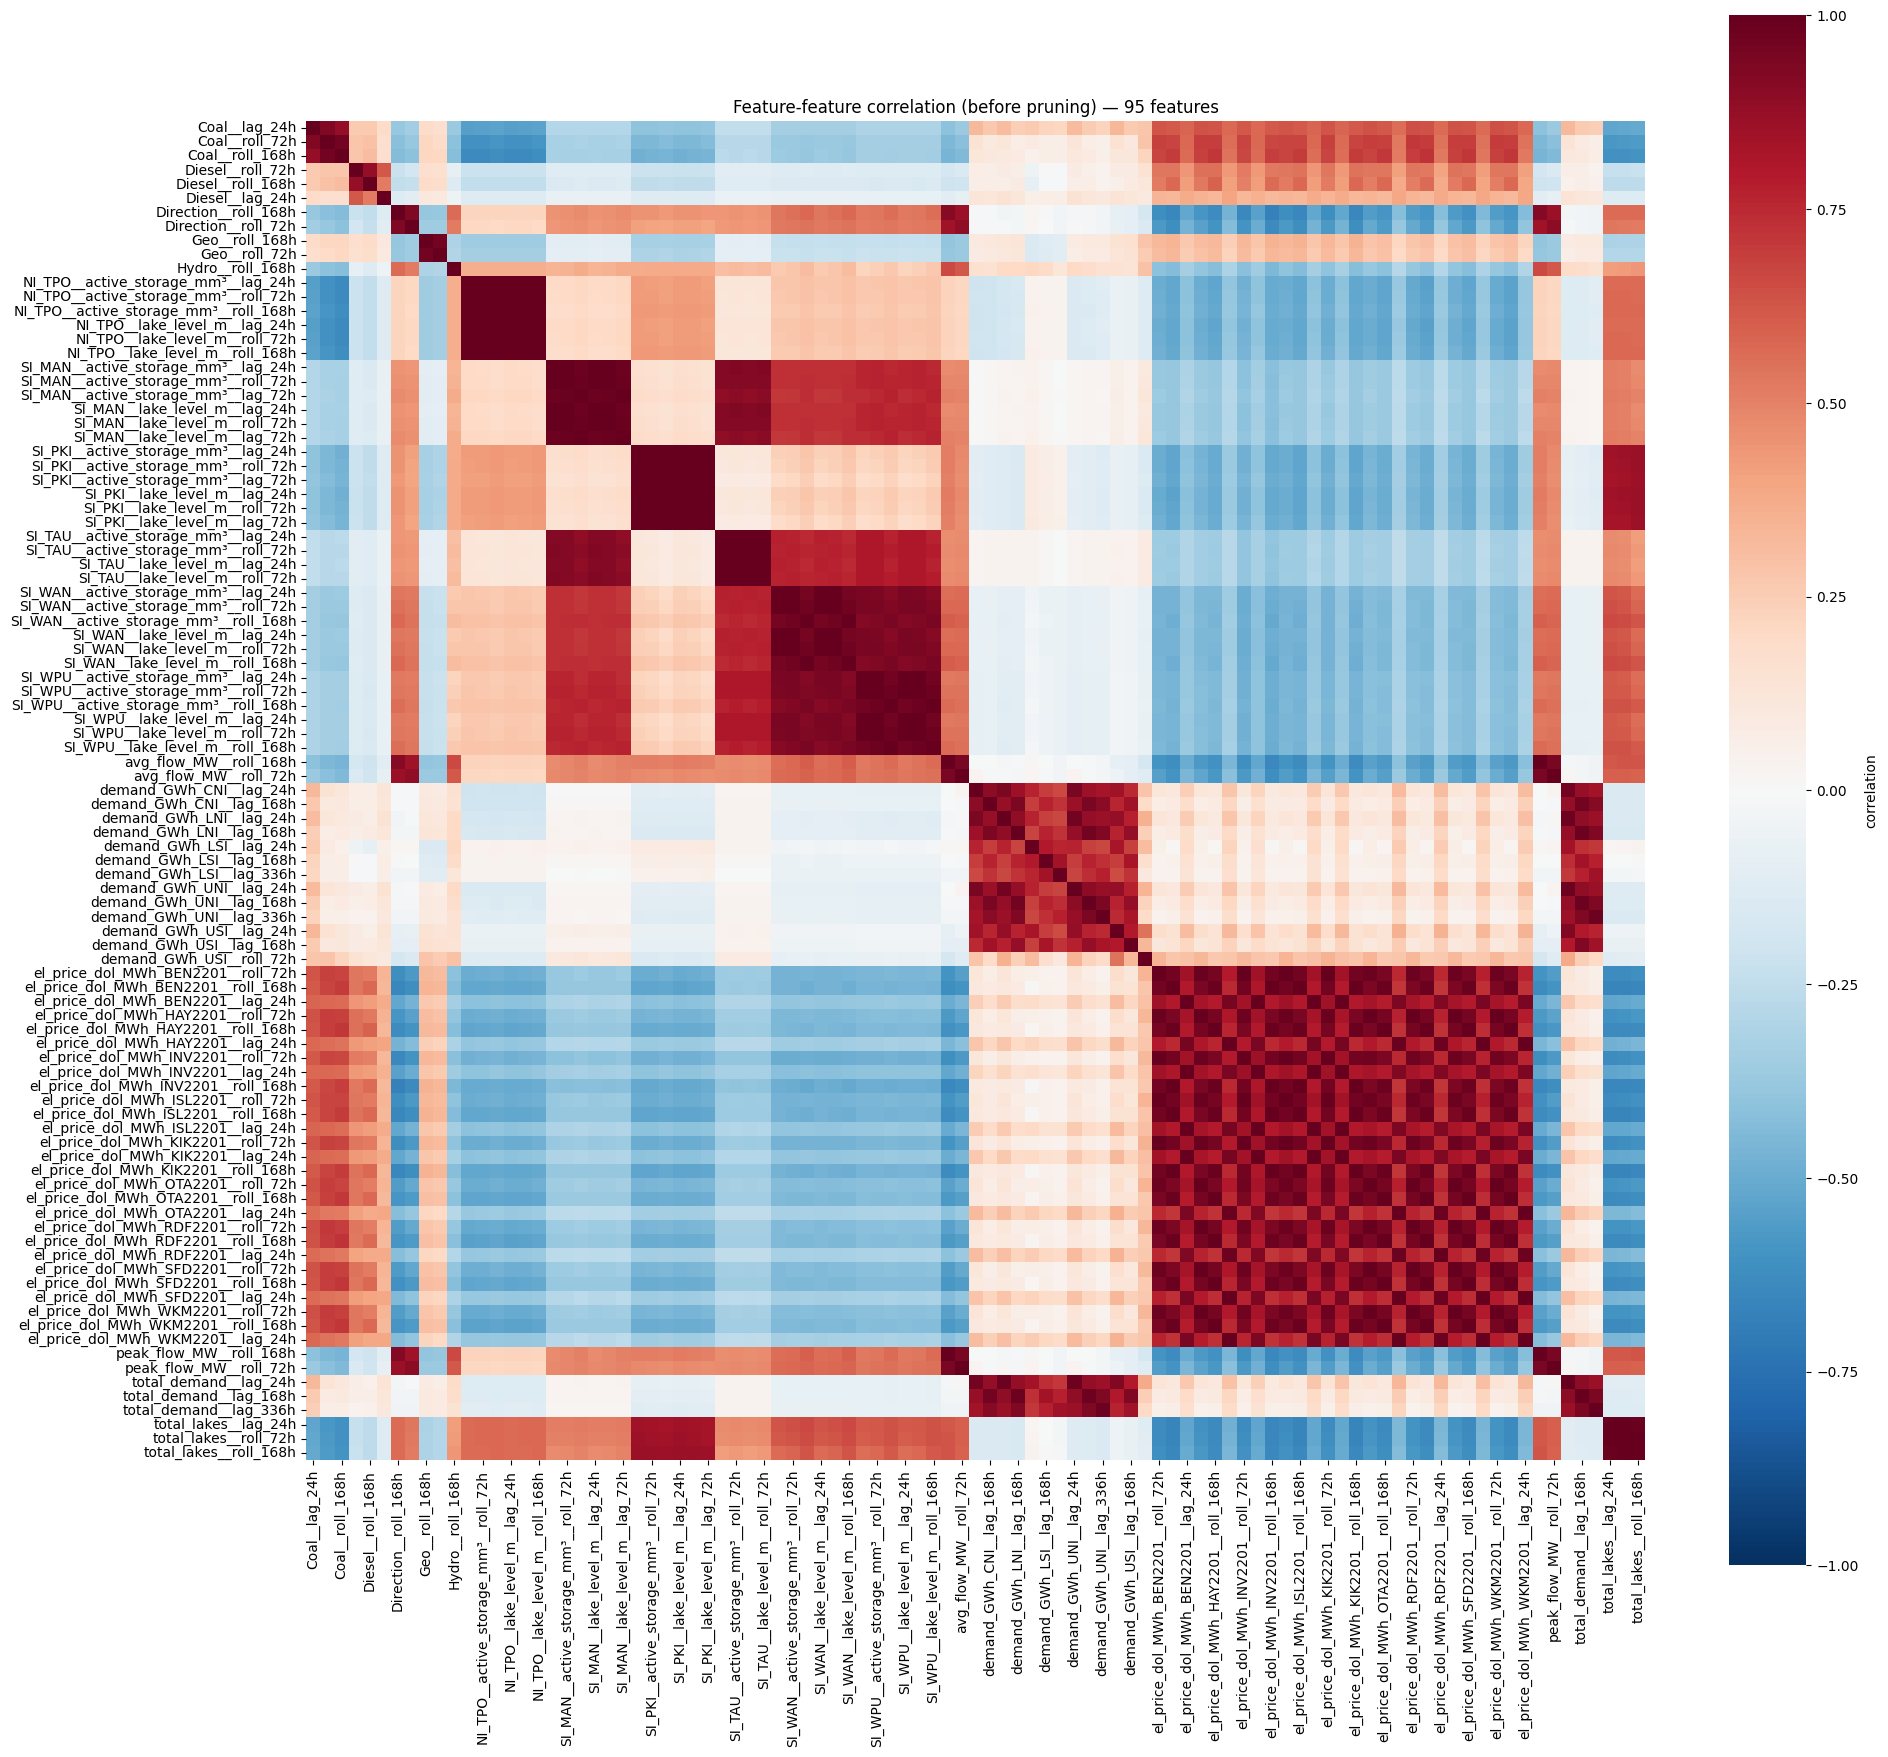


Pairs above |corr| >= 0.9: 364


,feat_a,feat_b,abs_corr
0,SI_WAN__active_storage_mm³__roll_168h,SI_WAN__lake_level_m__roll_168h,1.000000
1,SI_MAN__active_storage_mm³__roll_72h,SI_MAN__lake_level_m__roll_72h,1.000000
2,SI_TAU__active_storage_mm³__roll_72h,SI_TAU__lake_level_m__roll_72h,1.000000
3,SI_WAN__active_storage_mm³__roll_72h,SI_WAN__lake_level_m__roll_72h,1.000000
4,NI_TPO__active_storage_mm³__roll_168h,NI_TPO__lake_level_m__roll_168h,1.000000
5,SI_MAN__active_storage_mm³__lag_72h,SI_MAN__lake_level_m__lag_72h,1.000000
6,SI_MAN__active_storage_mm³__lag_24h,SI_MAN__lake_level_m__lag_24h,1.000000
7,SI_TAU__active_storage_mm³__lag_24h,SI_TAU__lake_level_m__lag_24h,1.000000
8,SI_WPU__active_storage_mm³__roll_168h,SI_WPU__lake_level_m__roll_168h,1.000000
9,SI_WAN__active_storage_mm³__lag_24h,SI_WAN__lake_level_m__lag_24h,1.000000


In [ ]:
multicoll_threshold = 0.9   # drop pairs above this

# --- Step 1: Build the lagged feature DataFrame ---
# This creates the actual columns XGBoost will see, one per (feature, lag) pair
# from feature_selection_dict

lag_map = {
    'corr_24h':         ('shift',   24),
    'corr_72h':         ('shift',   72),
    'corr_168h':        ('shift',  168),
    'corr_336h':        ('shift',  336),
    'corr_rolling_72':  ('rolling', 72),
    'corr_rolling_168': ('rolling', 168),
}

lagged_features = {}

for feat, lag_records in feature_selection_dict.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]

        if kind == 'shift':
            col_name = f'{feat}__lag_{n}h'
            lagged_features[col_name] = df[feat].shift(n)
        else:   # rolling mean
            col_name = f'{feat}__roll_{n}h'
            lagged_features[col_name] = df[feat].shift(1).rolling(window=n).mean()

X_features = pd.DataFrame(lagged_features, index=df.index)
print(f'Built feature matrix: {X_features.shape}')


# --- Step 2: Compute the feature-feature correlation matrix ---
# Drop NaN rows introduced by shifts/rolling (longest lag = 336h)
X_clean = X_features.dropna()
print(f'After dropping NaN rows: {X_clean.shape}')

feat_corr = X_clean.corr().abs()

# Zero out the diagonal and lower triangle so we only see each pair once
upper = feat_corr.where(
    np.triu(np.ones(feat_corr.shape), k=1).astype(bool)
)

# Visualize Multicollinearity
plt.figure(figsize=(20, 18))
sns.heatmap(X_clean.corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (before pruning) — {X_clean.shape[1]} features')
plt.tight_layout()
plt.show()


# --- Step 3: Find and rank highly-correlated pairs ---
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_a', 'level_1': 'feat_b', 0: 'abs_corr'})
    .query('abs_corr >= @multicoll_threshold')
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print(f'\nPairs above |corr| >= {multicoll_threshold}: {len(pairs)}')
pairs.head(30)

Features to drop: 75
Features to keep: 20
Final feature matrix: (96408, 20)


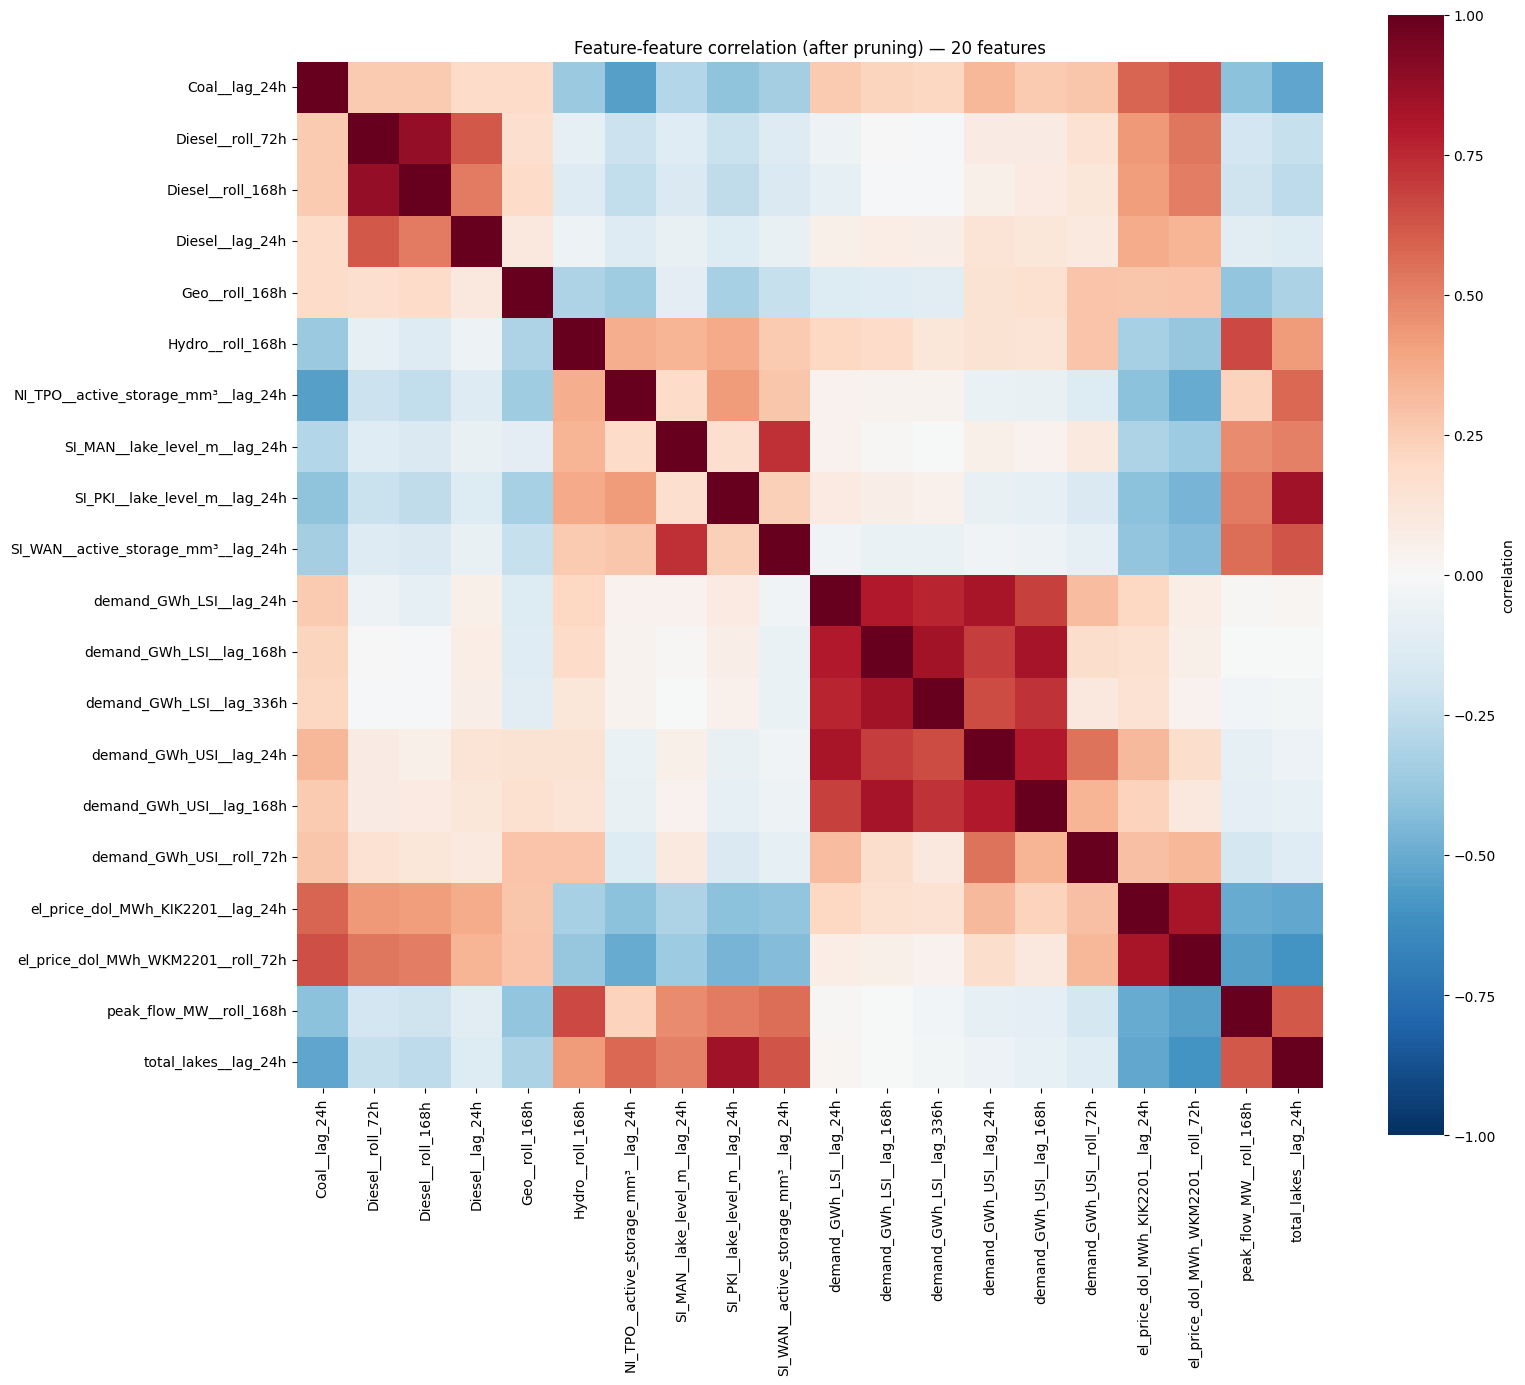

In [ ]:

# --- Step 4: Decide which features to drop ---
# For each high-correlation pair, drop the one with weaker target correlation

# Build a lookup: lagged-feature-name -> its target correlation
target_corr_lookup = {}
for feat, lag_records in feature_selection_dict.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]
        col_name = f'{feat}__lag_{n}h' if kind == 'shift' else f'{feat}__roll_{n}h'
        target_corr_lookup[col_name] = abs(record['lag_corr'])

to_drop = set()

for _, row in pairs.iterrows():
    a, b = row['feat_a'], row['feat_b']

    # If one is already dropped, skip
    if a in to_drop or b in to_drop:
        continue

    # Keep the one with stronger target correlation, drop the other
    if target_corr_lookup[a] >= target_corr_lookup[b]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f'Features to drop: {len(to_drop)}')
print(f'Features to keep: {X_features.shape[1] - len(to_drop)}')

X_final = X_features.drop(columns=list(to_drop))
print(f'Final feature matrix: {X_final.shape}')

# Visualize final choice
plt.figure(figsize=(16, 14))
sns.heatmap(X_final.dropna().corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (after pruning) — {X_final.shape[1]} features')
plt.tight_layout()
plt.show()

## LSTM — Feature Preparation Pipeline

- **Target correlation filter (`|corr| ≥ 0.10`)** — looser cutoff than XGBoost. LSTMs can find non-linear interactions that pure correlation misses, so we tolerate weaker linear signal in exchange for not discarding features that may interact non-linearly with others.

- **Do NOT pre-build lagged features** — unlike XGBoost, the LSTM sees a window of `INPUT_LENGTH = 168` hours of every feature as part of its 3D input tensor. Lags 1 through 168 are already available to the model "for free" through the input sequence. Building manual lag columns would just duplicate the same value in the input.

- **Keep long-horizon rolling features** — features summarising data *beyond* the input window (e.g., 30-day or 90-day rolling means) are genuinely useful because they provide context the LSTM cannot see inside its 168h window. These are not redundant.

- **Multicollinearity pruning (`|corr| > 0.95` between features)** — much looser threshold than XGBoost. The LSTM can combine correlated features however it wants internally, so only true near-duplicates need to go. Pruning here is for parameter efficiency, not correctness.

- **Cyclical time features** — `hour_sin`, `hour_cos`, `doy_sin`, `doy_cos`. The LSTM cannot infer absolute time-of-day or season from a window of values alone; these tell it where in the daily and yearly cycle each row sits.

- **Distribution review + transformations** — same as XGBoost: plot histograms, apply `log1p` to heavy right-tailed features. Done BEFORE the model's Normalization layer because that layer is StandardScaler, which squashes tails.

- **Built-in scaling via `Normalization` layer** — fitted on training data only via `adapt()`. No leakage. No need to scale manually before the model.

- **3D windowing via `get_X_y`** — the data prep we already wrote in the LSTM draft. Sliding window of (`INPUT_LENGTH`, `N_FEATURES`) → output of (`OUTPUT_LENGTH`,). Chronological train/val/test split.

- **Leakage check on input features** — same discipline as XGBoost: any feature whose value at hour `t` reflects information not yet available at real prediction time needs lagging or removal. Pure historical observations are safe.

In [ ]:
cutoff       = 0.10
top_n_lags   = 3      # keep top N lags per feature

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_72':  (corr_rolling_72_all,  'corr_rolling_72'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

# --- Collect ALL lag correlations per feature ---
feature_lags = {}   # feat -> list of (lag_name, corr_val)

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat         = row['feature']
        corr_lag_val = row[lag_col]

        if feat not in feature_lags:
            feature_lags[feat] = []
        feature_lags[feat].append((lag_name, corr_lag_val))

# --- For each feature: rank lags by |corr|, keep top N above cutoff ---
rows = []
for feat, lag_list in feature_lags.items():
    # Sort by absolute correlation, descending
    lag_list_sorted = sorted(lag_list, key=lambda x: abs(x[1]), reverse=True)

    # Keep top N that pass the cutoff
    kept = [(lag, corr) for lag, corr in lag_list_sorted[:top_n_lags] if abs(corr) >= cutoff]

    if not kept:
        continue   # feature has no lag passing the cutoff — drop entirely

    for rank, (lag_name, corr_val) in enumerate(kept, start=1):
        rows.append({
            'feature':  feat,
            'rank':     rank,
            'lag':      lag_name,
            'lag_corr': corr_val,
        })

# --- Build DataFrame ---
feature_selection_df = (
    pd.DataFrame(rows)
    .sort_values(['feature', 'rank'])
    .reset_index(drop=True)
)

# --- Build dictionary: feature -> list of {lag, corr} dicts (ranked) ---
feature_selection_dict = {}
for feat, group in feature_selection_df.groupby('feature', sort=False):
    feature_selection_dict[feat] = group[['rank', 'lag', 'lag_corr']].to_dict(orient='records')

# --- Reporting ---
unique_features_kept = feature_selection_df['feature'].nunique()
total_lag_rows       = len(feature_selection_df)
features_dropped     = len(corr_24_all) - unique_features_kept

print(f'Cutoff: |corr| >= {cutoff}, top {top_n_lags} lags per feature')
print(f'Features kept:    {unique_features_kept}')
print(f'Features dropped: {features_dropped}')
print(f'Total lag-rows:   {total_lag_rows}   (each feature contributes up to {top_n_lags} rows)')
print()
feature_selection_df

## Linear Model — Feature Preparation Pipeline

- **Target correlation filter (`|corr| ≥ 0.20`)** — same cutoff as XGBoost. Linear models can only capture linear relationships, so features with weak linear correlation contribute little.

- **Keep top 2–3 lags per surviving feature** — same as XGBoost. Multiple lags carry different temporal information; the linear model assigns each its own coefficient.

- **Multicollinearity pruning (`|corr| > 0.7` between features)** — much stricter threshold than XGBoost or LSTM. Linear models are uniquely sensitive to multicollinearity: correlated features cause coefficient instability, inflated standard errors, and unreliable feature importance. This is the hardest constraint of the three pipelines.

- **Distribution review + transformations** — apply `log1p` to heavy-tailed features. Linear models assume a linear relationship between features and target; transformations help when the underlying relationship is multiplicative or saturating.

- **StandardScaler is essential** — linear models with regularisation (Ridge, Lasso, ElasticNet) treat features with larger scale as less penalised. Unscaled features will dominate the model artificially. Fit the scaler on training data only, then transform val/test with the same fitted scaler.

- **Consider polynomial or interaction features** — linear models cannot learn interactions on their own. If you suspect feature interactions matter (e.g., `temperature × demand`), build them explicitly. Use sparingly: each interaction adds a column.

- **Cyclical time features** — same as LSTM: `hour_sin`, `hour_cos`, `doy_sin`, `doy_cos`. Linear models cannot use raw `hour` (0–23) sensibly because 23 and 0 look maximally distant when they should be adjacent.

- **Train/validation/test split — chronological** — same discipline as the other models. Never shuffle time series data.

- **Leakage check on input features** — same as XGBoost and LSTM.

In [ ]:
cutoff       = 0.20
top_n_lags   = 3      # keep top N lags per feature

all_corr_dfs = {
    'corr_24h':         (corr_24_all,          'corr_24h'),
    'corr_72h':         (corr_72_all,          'corr_72h'),
    'corr_168h':        (corr_168_all,         'corr_168h'),
    'corr_336h':        (corr_336_all,         'corr_336h'),
    'corr_rolling_72':  (corr_rolling_72_all,  'corr_rolling_72'),
    'corr_rolling_168': (corr_rolling_168_all, 'corr_rolling_168'),
}

# --- Collect ALL lag correlations per feature ---
feature_lags = {}   # feat -> list of (lag_name, corr_val)

for lag_name, (df_corr, lag_col) in all_corr_dfs.items():
    for _, row in df_corr.iterrows():
        feat         = row['feature']
        corr_lag_val = row[lag_col]

        if feat not in feature_lags:
            feature_lags[feat] = []
        feature_lags[feat].append((lag_name, corr_lag_val))

# --- For each feature: rank lags by |corr|, keep top N above cutoff ---
rows = []
for feat, lag_list in feature_lags.items():
    # Sort by absolute correlation, descending
    lag_list_sorted = sorted(lag_list, key=lambda x: abs(x[1]), reverse=True)

    # Keep top N that pass the cutoff
    kept = [(lag, corr) for lag, corr in lag_list_sorted[:top_n_lags] if abs(corr) >= cutoff]

    if not kept:
        continue   # feature has no lag passing the cutoff — drop entirely

    for rank, (lag_name, corr_val) in enumerate(kept, start=1):
        rows.append({
            'feature':  feat,
            'rank':     rank,
            'lag':      lag_name,
            'lag_corr': corr_val,
        })

# --- Build DataFrame ---
feature_selection_df_lin = (
    pd.DataFrame(rows)
    .sort_values(['feature', 'rank'])
    .reset_index(drop=True)
)

# --- Build dictionary: feature -> list of {lag, corr} dicts (ranked) ---
feature_selection_dict_lin = {}
for feat, group in feature_selection_df_lin.groupby('feature', sort=False):
    feature_selection_dict_lin[feat] = group[['rank', 'lag', 'lag_corr']].to_dict(orient='records')

# --- Reporting ---
unique_features_kept = feature_selection_df_lin['feature'].nunique()
total_lag_rows       = len(feature_selection_df_lin)
features_dropped     = len(corr_24_all) - unique_features_kept

print(f'Cutoff: |corr| >= {cutoff}, top {top_n_lags} lags per feature')
print(f'Features kept:    {unique_features_kept}')
print(f'Features dropped: {features_dropped}')
print(f'Total lag-rows:   {total_lag_rows}   (each feature contributes up to {top_n_lags} rows)')
print()
feature_selection_df_lin

Cutoff: |corr| >= 0.2, top 3 lags per feature
Features kept:    35
Features dropped: 49
Total lag-rows:   95   (each feature contributes up to 3 rows)



,feature,rank,lag,lag_corr
0,Coal,1,corr_24h,0.502964
1,Coal,2,corr_rolling_72,0.492208
2,Coal,3,corr_rolling_168,0.488340
3,Diesel,1,corr_rolling_72,0.351319
4,Diesel,2,corr_rolling_168,0.338182
...,...,...,...,...
90,total_demand,2,corr_168h,0.238803
91,total_demand,3,corr_336h,0.217486
92,total_lakes,1,corr_24h,-0.331876
93,total_lakes,2,corr_rolling_72,-0.329161


Built feature matrix: (96408, 95)
After dropping NaN rows: (57362, 95)


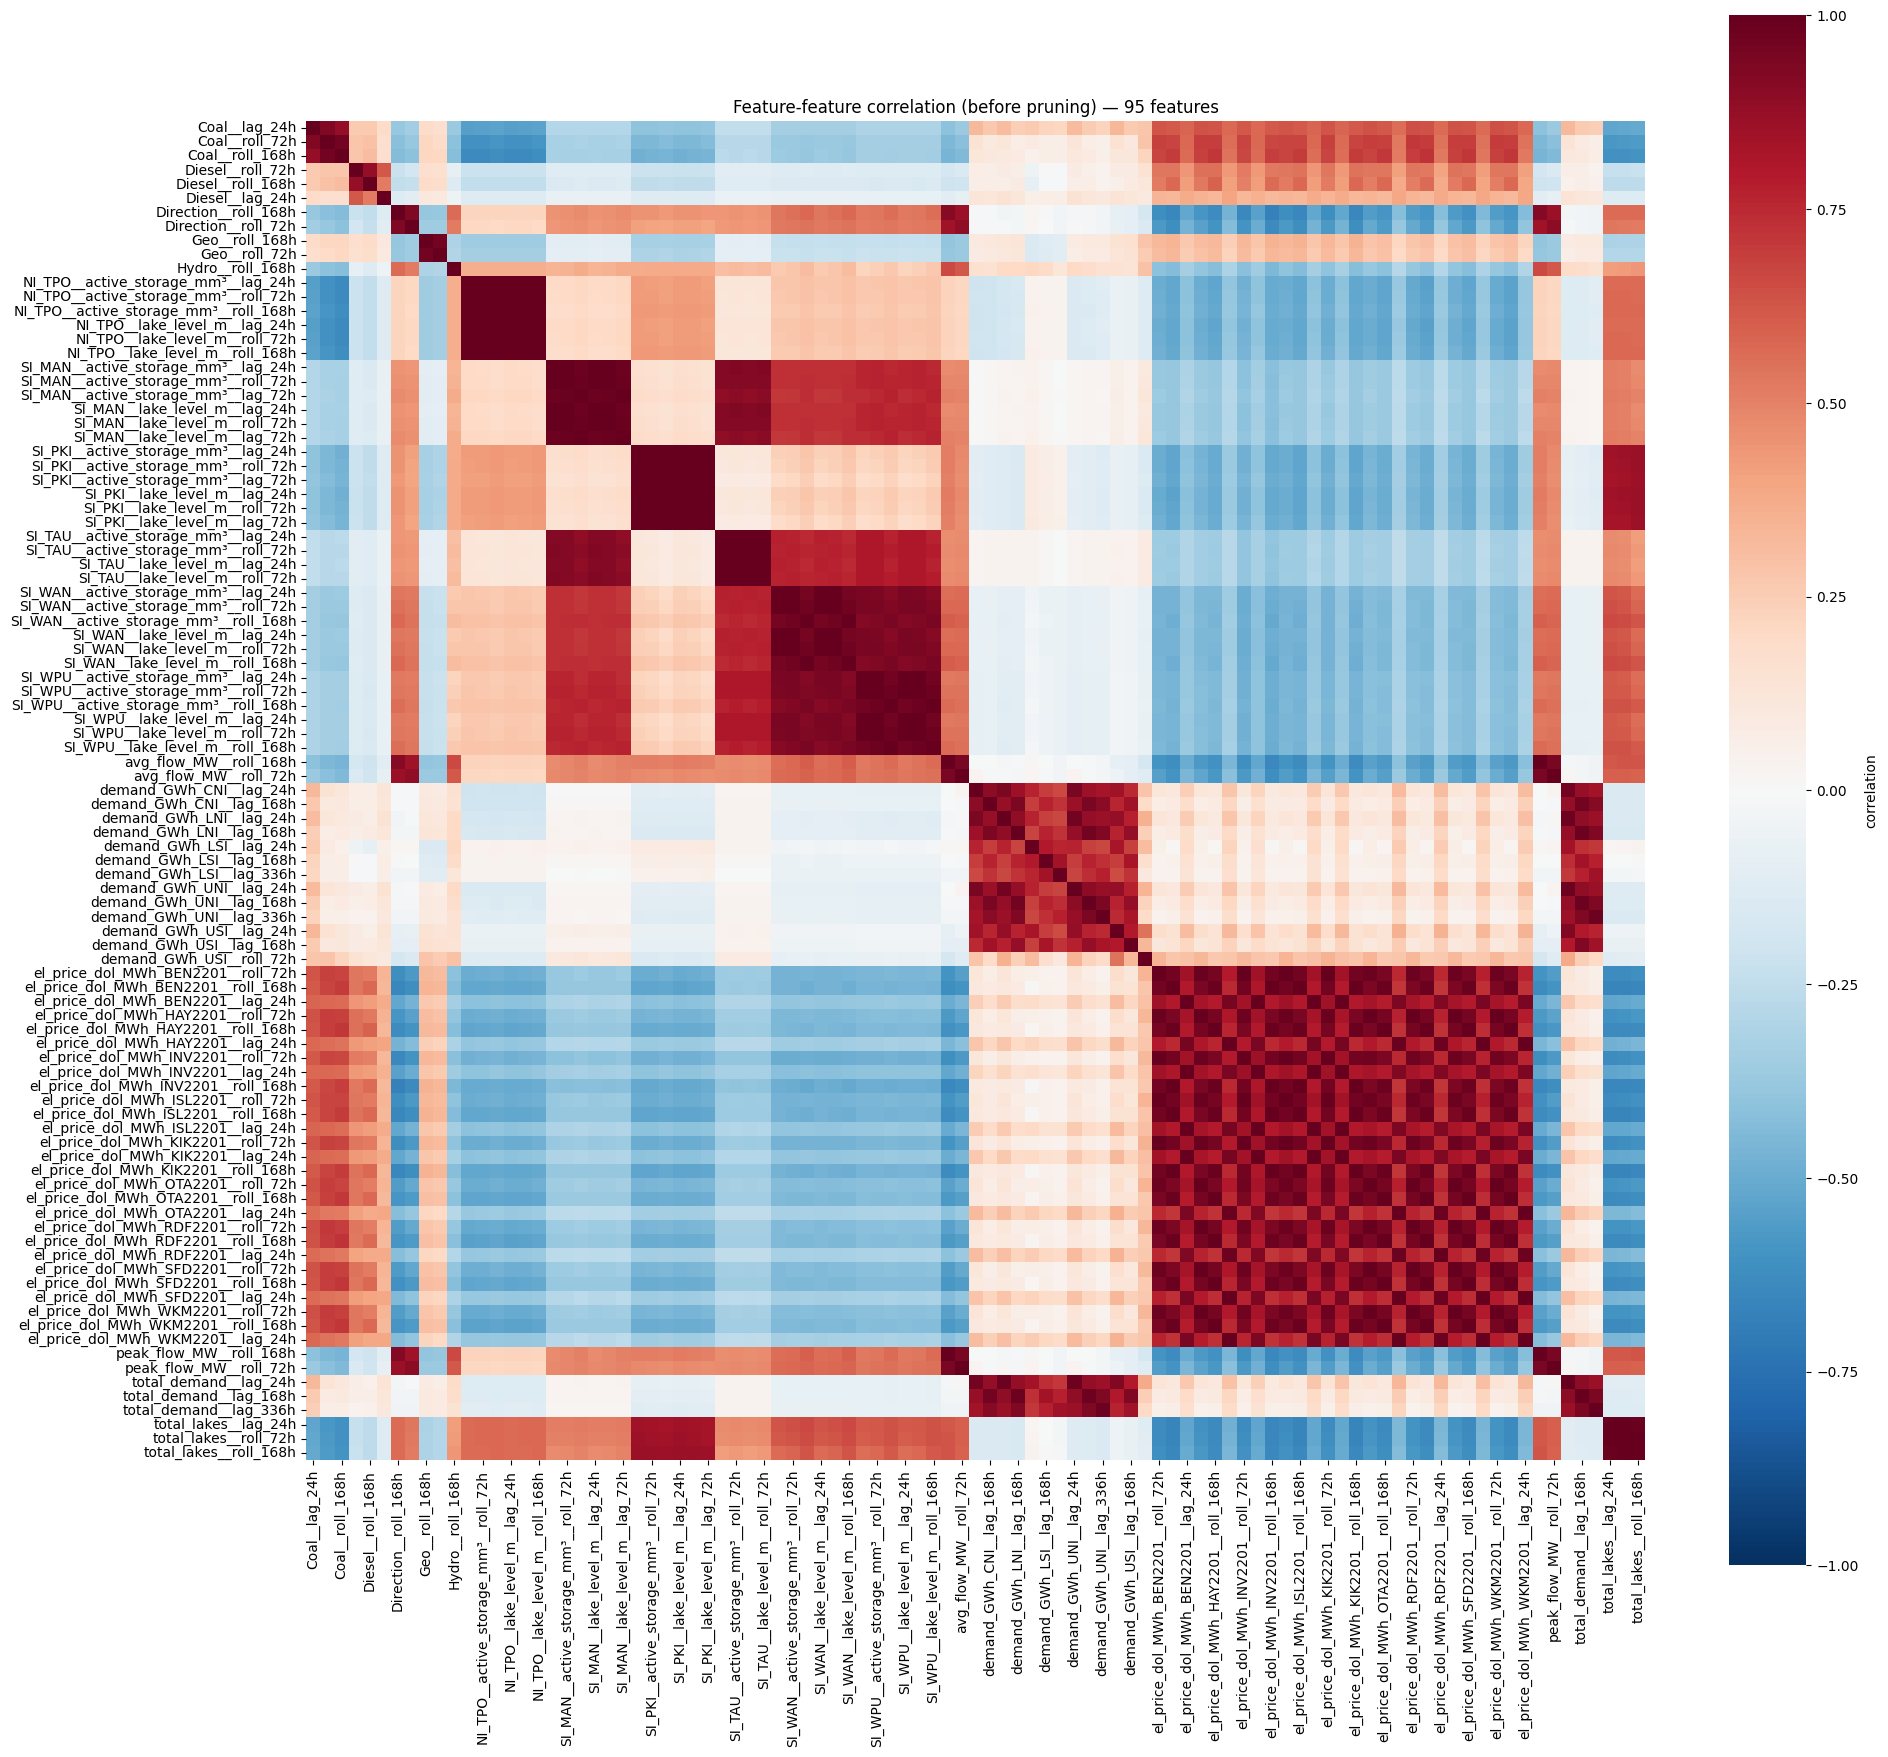


Pairs above |corr| >= 0.7: 752


,feat_a,feat_b,abs_corr
0,SI_WAN__active_storage_mm³__roll_168h,SI_WAN__lake_level_m__roll_168h,1.000000
1,SI_MAN__active_storage_mm³__roll_72h,SI_MAN__lake_level_m__roll_72h,1.000000
2,SI_TAU__active_storage_mm³__roll_72h,SI_TAU__lake_level_m__roll_72h,1.000000
3,SI_WAN__active_storage_mm³__roll_72h,SI_WAN__lake_level_m__roll_72h,1.000000
4,NI_TPO__active_storage_mm³__roll_168h,NI_TPO__lake_level_m__roll_168h,1.000000
5,SI_MAN__active_storage_mm³__lag_72h,SI_MAN__lake_level_m__lag_72h,1.000000
6,SI_MAN__active_storage_mm³__lag_24h,SI_MAN__lake_level_m__lag_24h,1.000000
7,SI_TAU__active_storage_mm³__lag_24h,SI_TAU__lake_level_m__lag_24h,1.000000
8,SI_WPU__active_storage_mm³__roll_168h,SI_WPU__lake_level_m__roll_168h,1.000000
9,SI_WAN__active_storage_mm³__lag_24h,SI_WAN__lake_level_m__lag_24h,1.000000


In [ ]:
multicoll_threshold = 0.7   # drop pairs above this

# --- Step 1: Build the lagged feature DataFrame ---
# This creates the actual columns XGBoost will see, one per (feature, lag) pair
# from feature_selection_dict_lin

lag_map = {
    'corr_24h':         ('shift',   24),
    'corr_72h':         ('shift',   72),
    'corr_168h':        ('shift',  168),
    'corr_336h':        ('shift',  336),
    'corr_rolling_72':  ('rolling', 72),
    'corr_rolling_168': ('rolling', 168),
}

lagged_features = {}

for feat, lag_records in feature_selection_dict_lin.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]

        if kind == 'shift':
            col_name = f'{feat}__lag_{n}h'
            lagged_features[col_name] = df[feat].shift(n)
        else:   # rolling mean
            col_name = f'{feat}__roll_{n}h'
            lagged_features[col_name] = df[feat].shift(1).rolling(window=n).mean()

X_features = pd.DataFrame(lagged_features, index=df.index)
print(f'Built feature matrix: {X_features.shape}')


# --- Step 2: Compute the feature-feature correlation matrix ---
# Drop NaN rows introduced by shifts/rolling (longest lag = 336h)
X_clean = X_features.dropna()
print(f'After dropping NaN rows: {X_clean.shape}')

feat_corr = X_clean.corr().abs()

# Zero out the diagonal and lower triangle so we only see each pair once
upper = feat_corr.where(
    np.triu(np.ones(feat_corr.shape), k=1).astype(bool)
)

# Visualize Multicollinearity
plt.figure(figsize=(20, 18))
sns.heatmap(X_clean.corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (before pruning) — {X_clean.shape[1]} features')
plt.tight_layout()
plt.show()


# --- Step 3: Find and rank highly-correlated pairs ---
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feat_a', 'level_1': 'feat_b', 0: 'abs_corr'})
    .query('abs_corr >= @multicoll_threshold')
    .sort_values('abs_corr', ascending=False)
    .reset_index(drop=True)
)

print(f'\nPairs above |corr| >= {multicoll_threshold}: {len(pairs)}')
pairs.head(30)

In [ ]:

# --- Step 4: Decide which features to drop ---
# For each high-correlation pair, drop the one with weaker target correlation

# Build a lookup: lagged-feature-name -> its target correlation
target_corr_lookup = {}
for feat, lag_records in feature_selection_df_lin.items():
    for record in lag_records:
        lag_name = record['lag']
        kind, n  = lag_map[lag_name]
        col_name = f'{feat}__lag_{n}h' if kind == 'shift' else f'{feat}__roll_{n}h'
        target_corr_lookup[col_name] = abs(record['lag_corr'])

to_drop = set()

for _, row in pairs.iterrows():
    a, b = row['feat_a'], row['feat_b']

    # If one is already dropped, skip
    if a in to_drop or b in to_drop:
        continue

    # Keep the one with stronger target correlation, drop the other
    if target_corr_lookup[a] >= target_corr_lookup[b]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f'Features to drop: {len(to_drop)}')
print(f'Features to keep: {X_features.shape[1] - len(to_drop)}')

X_final = X_features.drop(columns=list(to_drop))
print(f'Final feature matrix: {X_final.shape}')

# Visualize final choice
plt.figure(figsize=(16, 14))
sns.heatmap(X_final.dropna().corr(),
            cmap='RdBu_r',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={'label': 'correlation'})
plt.title(f'Feature-feature correlation (after pruning) — {X_final.shape[1]} features')
plt.tight_layout()
plt.show()

TypeError: string indices must be integers